Artificial Intelligence for Communication and Marketing

The Chief Marketing Officer (CMO) of a leading retail e-commerce platform has raised concerns about a growing rate of customer attrition, negatively impacting average order value and overall customer lifetime value (CLV). To counter this trend, the CMO has tasked the Data & AI team with developing a predictive model capable of identifying customers who are at high risk of churning.
The insights generated will be used to inform proactive retention strategies such as personalized offers and targeted communications, aiming to boost loyalty and profitability. The executive team considers this project a key step toward enhancing customer retention, improving marketing effectiveness, and sustaining revenue growth.

**1. Import Libraries**

In [60]:
%pip install numpy pandas matplotlib seaborn scikit-learn xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, silhouette_score


Note: you may need to restart the kernel to use updated packages.


**2. Load the dataset**

In [61]:
# Install openpyxl for reading Excel files
%pip install openpyxl    

# Load the dataset from an Excel file
df = pd.read_excel("data.xlsx")
df.head(10)

Note: you may need to restart the kernel to use updated packages.


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001.0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002.0,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003.0,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004.0,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005.0,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006.0,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007.0,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008.0,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009.0,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010.0,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [62]:
df.info() # Display basic information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5628 non-null   float64
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5628 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [63]:
df.shape

(5630, 20)

In [64]:
df.nunique()  # Count unique values in each column


CustomerID                     5628
Churn                             2
Tenure                           36
PreferredLoginDevice              4
CityTier                          3
WarehouseToHome                  34
PreferredPaymentMode              7
Gender                            2
HourSpendOnApp                    6
NumberOfDeviceRegistered          6
PreferedOrderCat                  6
SatisfactionScore                 5
MaritalStatus                     4
NumberOfAddress                  15
Complain                          2
OrderAmountHikeFromlastYear      16
CouponUsed                       17
OrderCount                       16
DaySinceLastOrder                22
CashbackAmount                 2587
dtype: int64

In [ ]:
##Coloumn Transformation

# int columns to convert to string
int_cols = ['CityTier', 'NumberOfAddress', 'Complain', 'SatisfactionScore', 'NumberOfDeviceRegistered','Churn'] # Columns to be transformed from int to string

# Transform selected columns: int -> string
for col in int_cols:
	df[col] = pd.to_numeric(df[col], errors='coerce').dropna().astype(str)

# Transform selected columns: float -> int -> string (handle NaNs safely)
feature_cols = [ 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount']

for col in feature_cols:
	# Convert to float, then to int (ignoring NaNs), then to string
	df[col] = pd.to_numeric(df[col], errors='coerce').dropna().astype(int).astype(str)

In [66]:
df.info()  # Check the data types after transformation

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5628 non-null   float64
 1   Churn                        5630 non-null   object 
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   object 
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5628 non-null   object 
 8   HourSpendOnApp               5375 non-null   object 
 9   NumberOfDeviceRegistered     5630 non-null   object 
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   object 
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [67]:
df_raw = df.copy()

In [ ]:
# break variables into categorical and numerical

categorical_cols = (df_raw.dtypes[df_raw.dtypes == 'object'].index)
numerical_cols = df_raw.dtypes[df_raw.dtypes != 'object'].index.drop('CustomerID')

In [69]:
# Check unique values of each column in the dataset using a for loop
for column in categorical_cols:
        print("Column: {} - Unique Values: {}".format(column, df_raw[column].unique()))
        print("="*80) 

Column: Churn - Unique Values: ['1' '0']
Column: PreferredLoginDevice - Unique Values: ['Mobile Phone' 'Phone' 'Computer' 'N.A.']
Column: CityTier - Unique Values: ['3' '1' '2']
Column: PreferredPaymentMode - Unique Values: ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
Column: Gender - Unique Values: ['Female' 'Male' nan]
Column: HourSpendOnApp - Unique Values: ['3' '2' nan '1' '0' '4' '5']
Column: NumberOfDeviceRegistered - Unique Values: ['3' '4' '5' '2' '1' '6']
Column: PreferedOrderCat - Unique Values: ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
Column: SatisfactionScore - Unique Values: ['2' '3' '5' '4' '1']
Column: MaritalStatus - Unique Values: ['Single' 'Divorced' 'Married' 'Widow']
Column: NumberOfAddress - Unique Values: ['9' '7' '6' '8' '3' '2' '4' '10' '1' '5' '19' '21' '11' '20' '22']
Column: Complain - Unique Values: ['1' '0']
Column: OrderAmountHikeFromlastYear - Unique Values: ['11' '15' '14' '23' '22' '16' '

**3.Explorative Data Analysis(EDA)**

Categorical variables

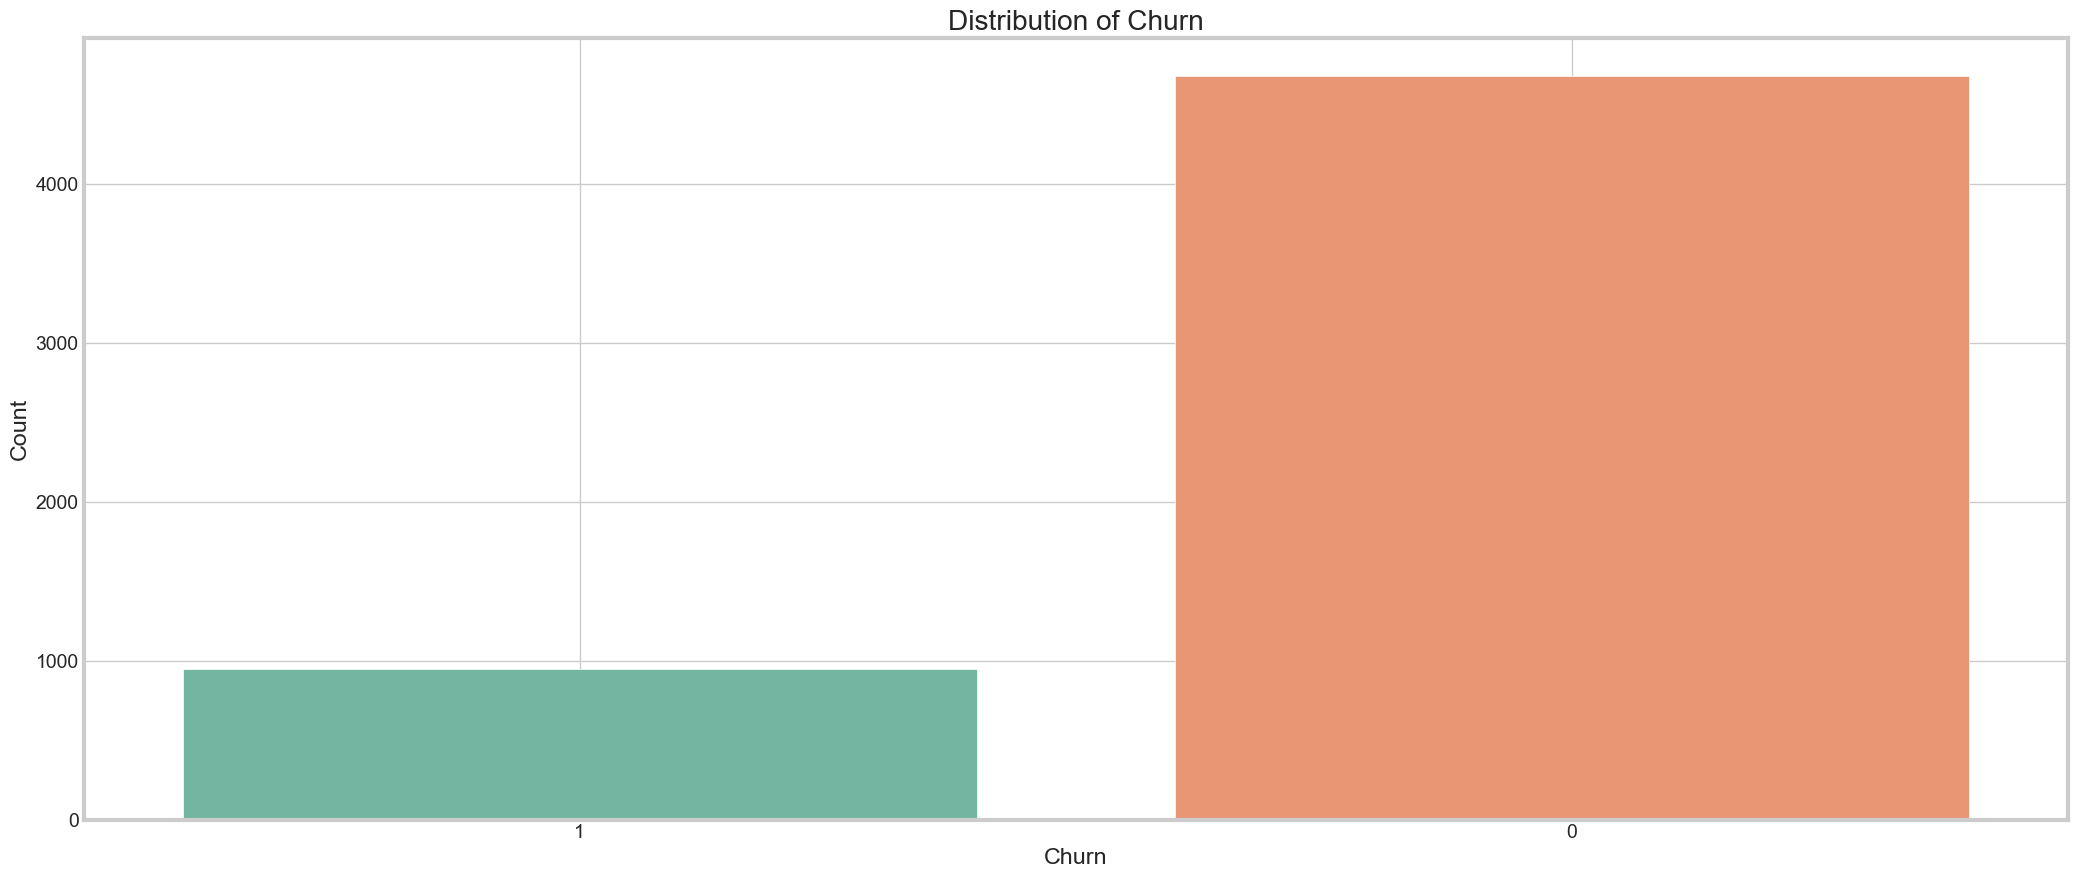

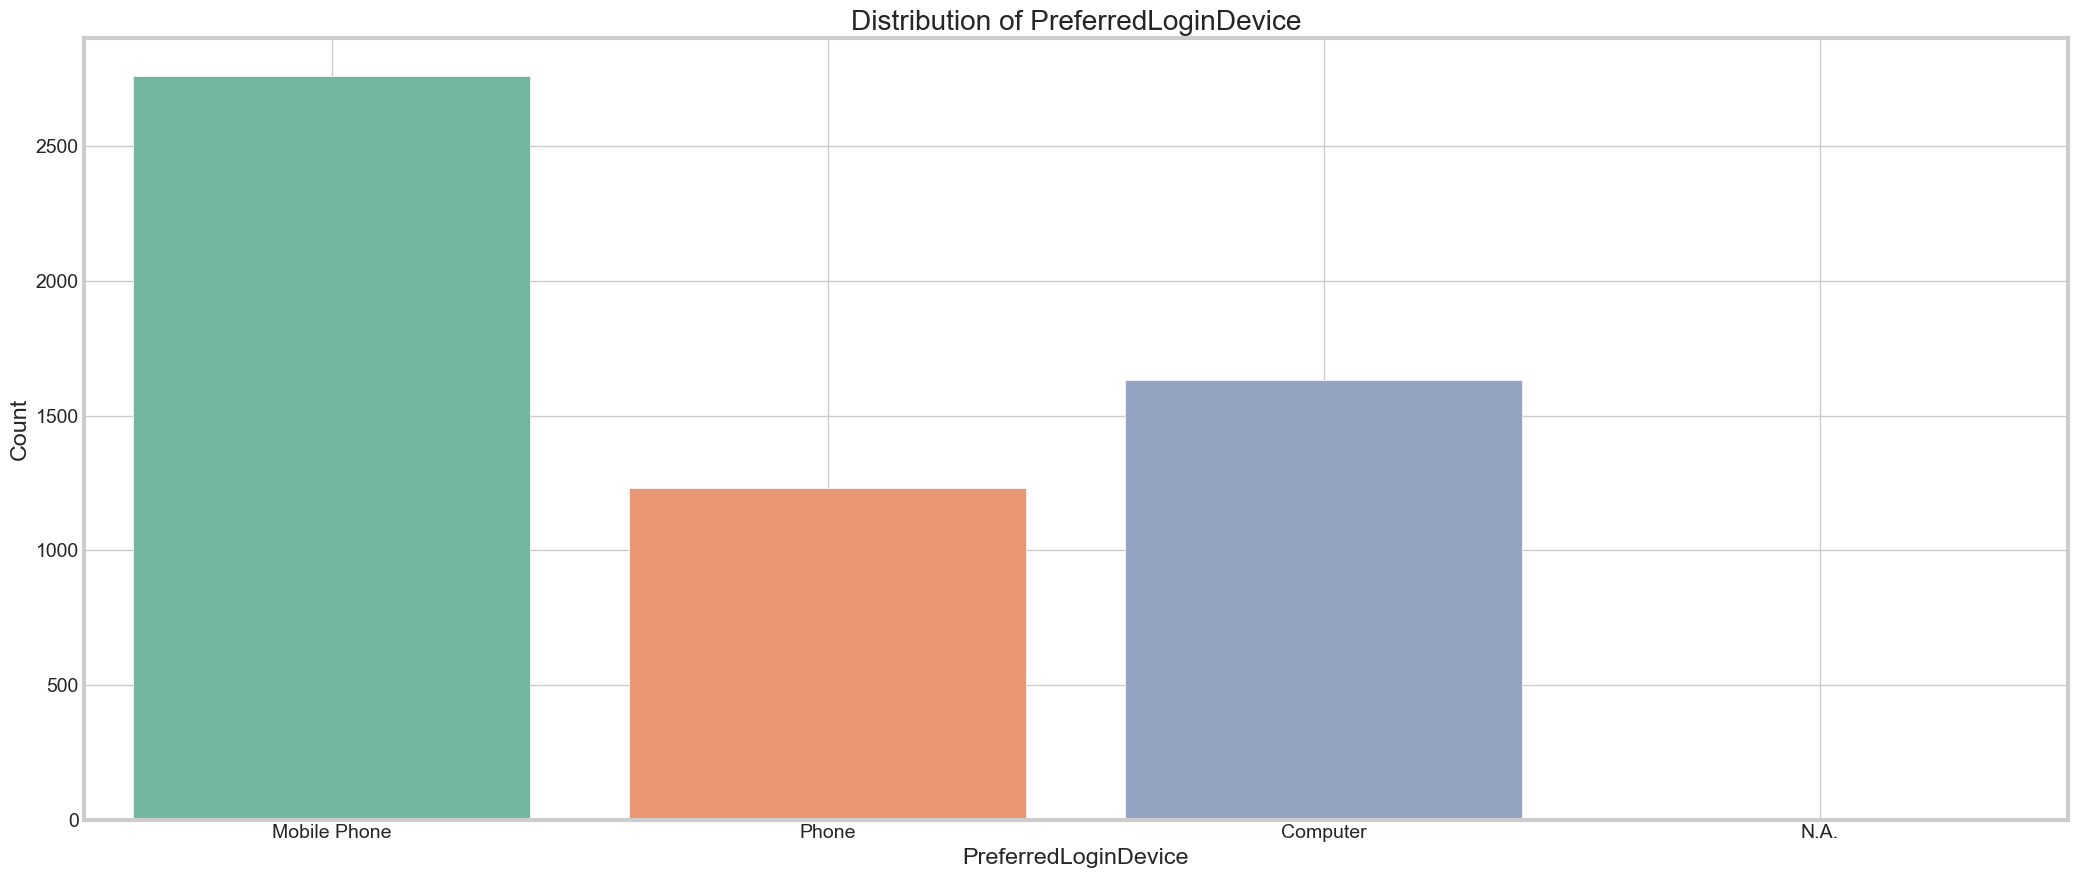

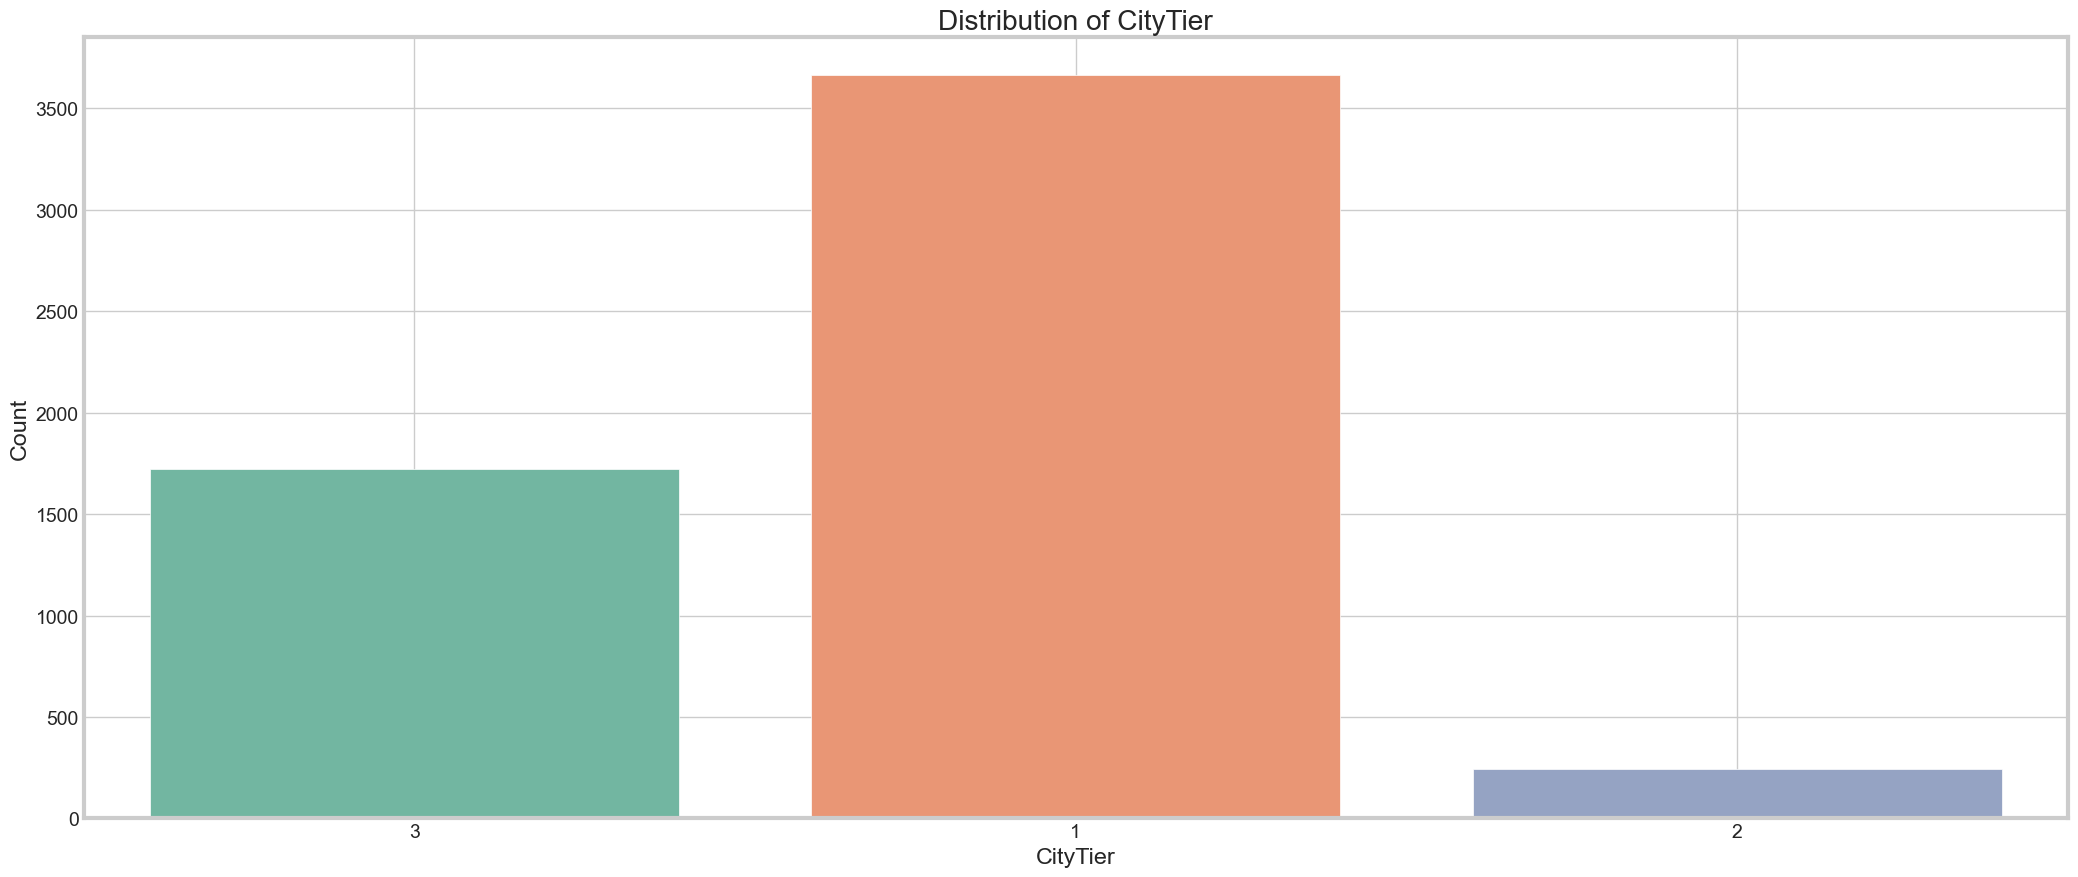

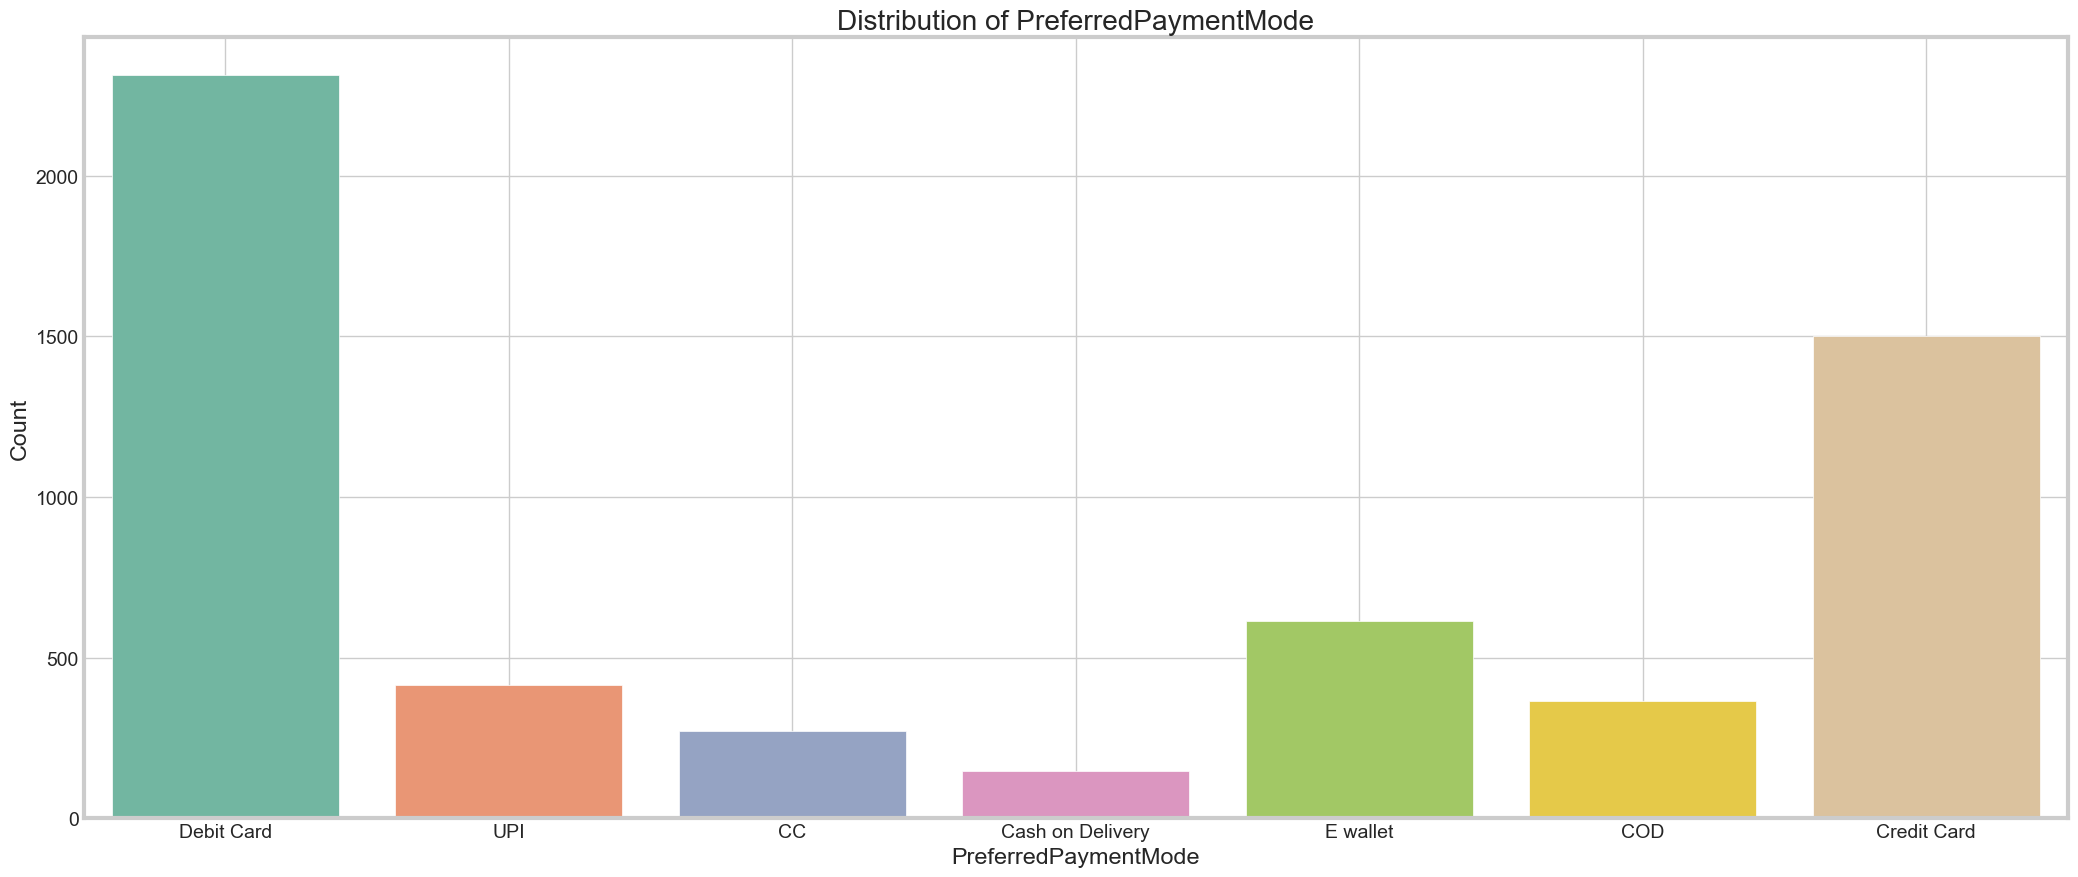

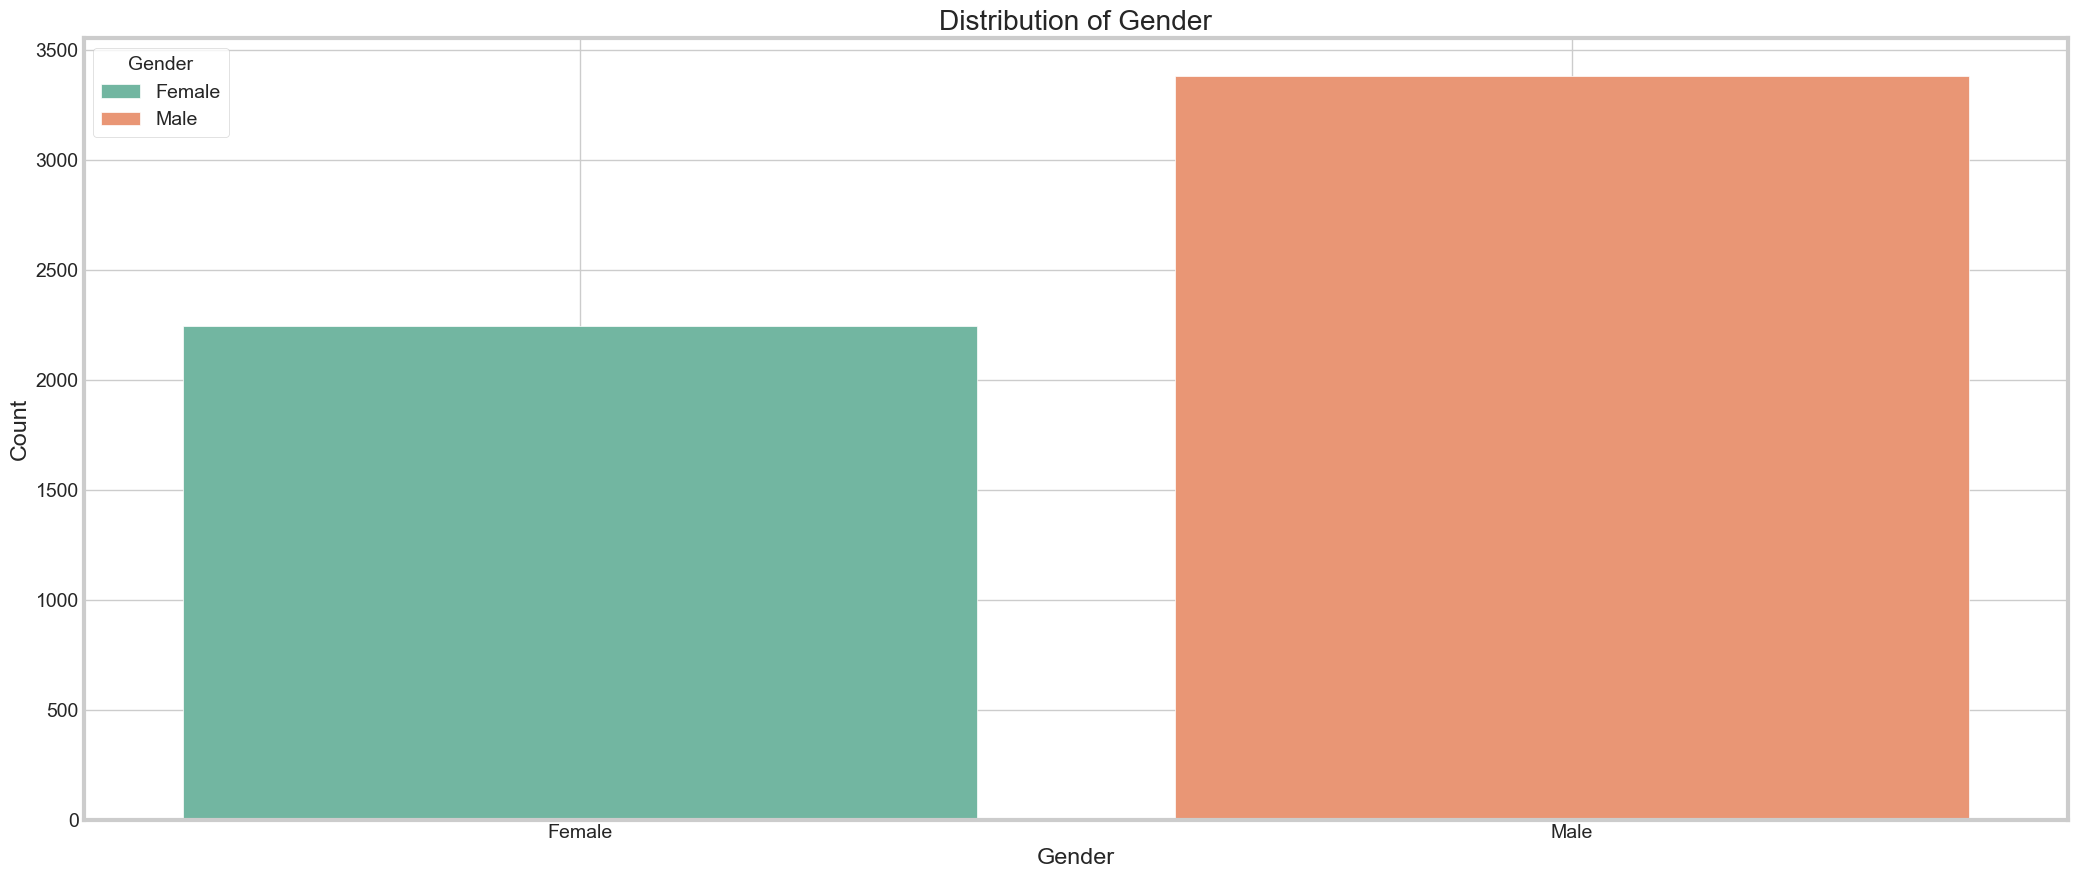

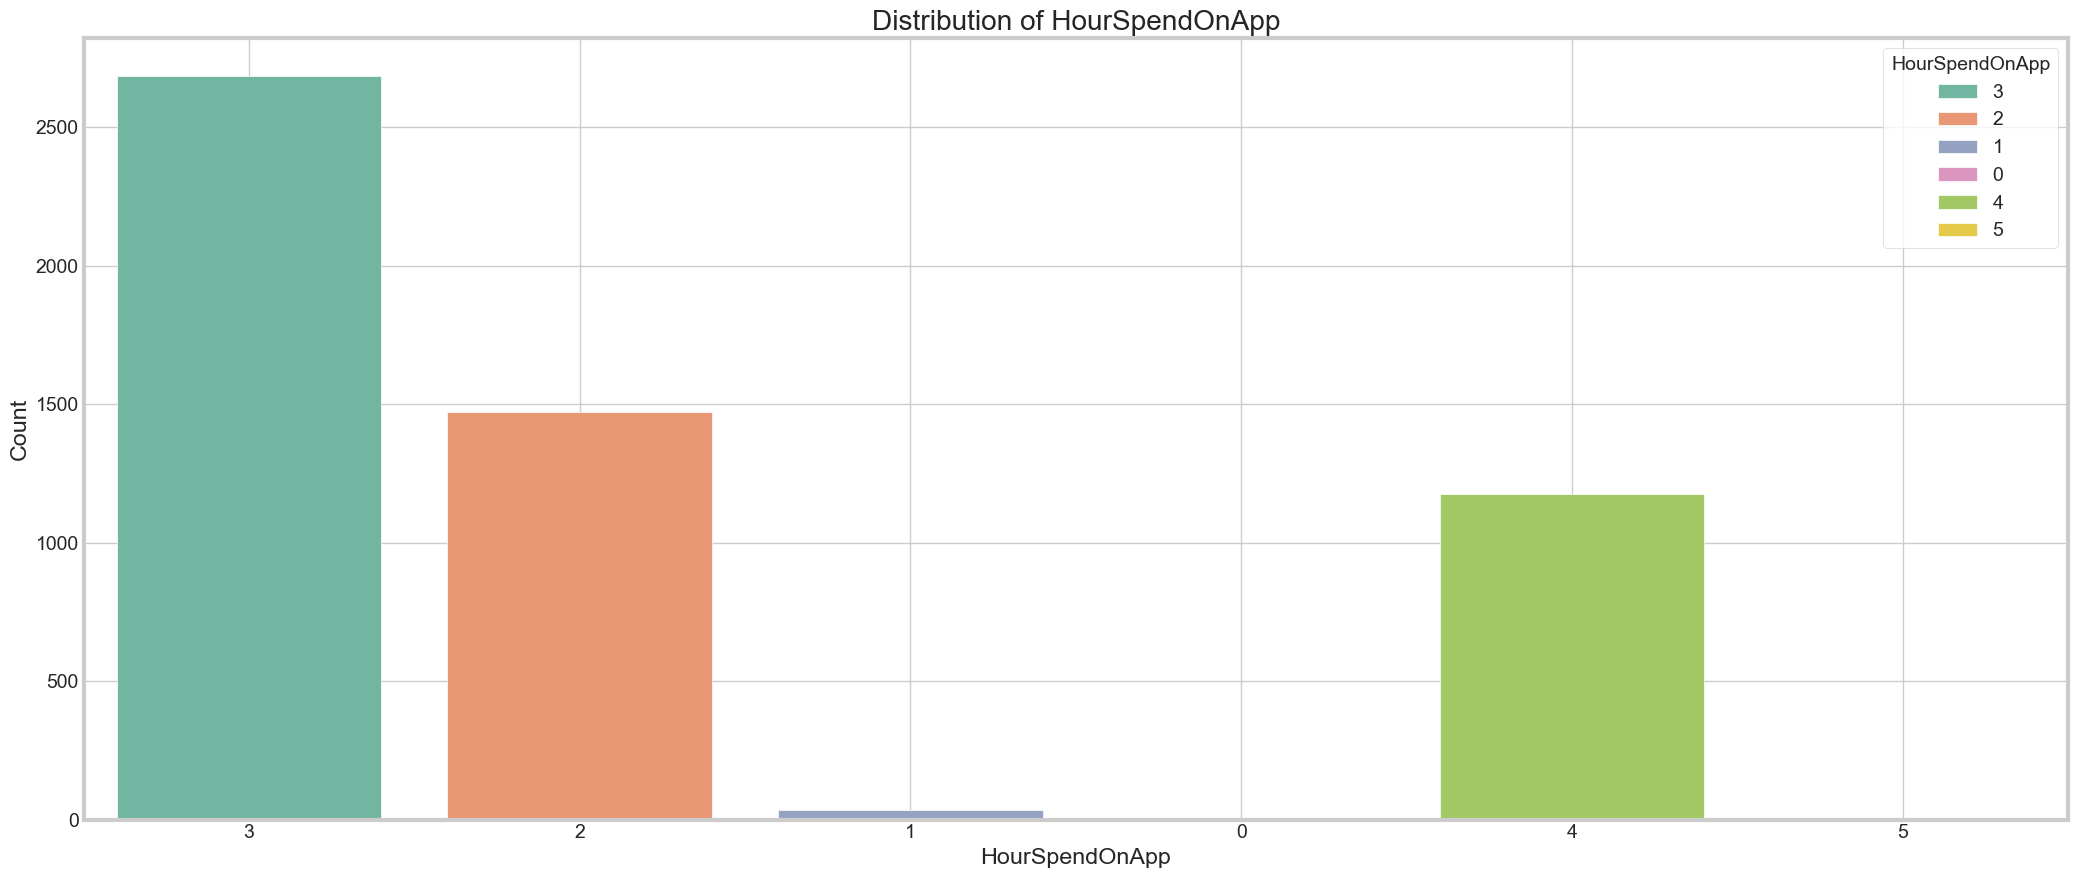

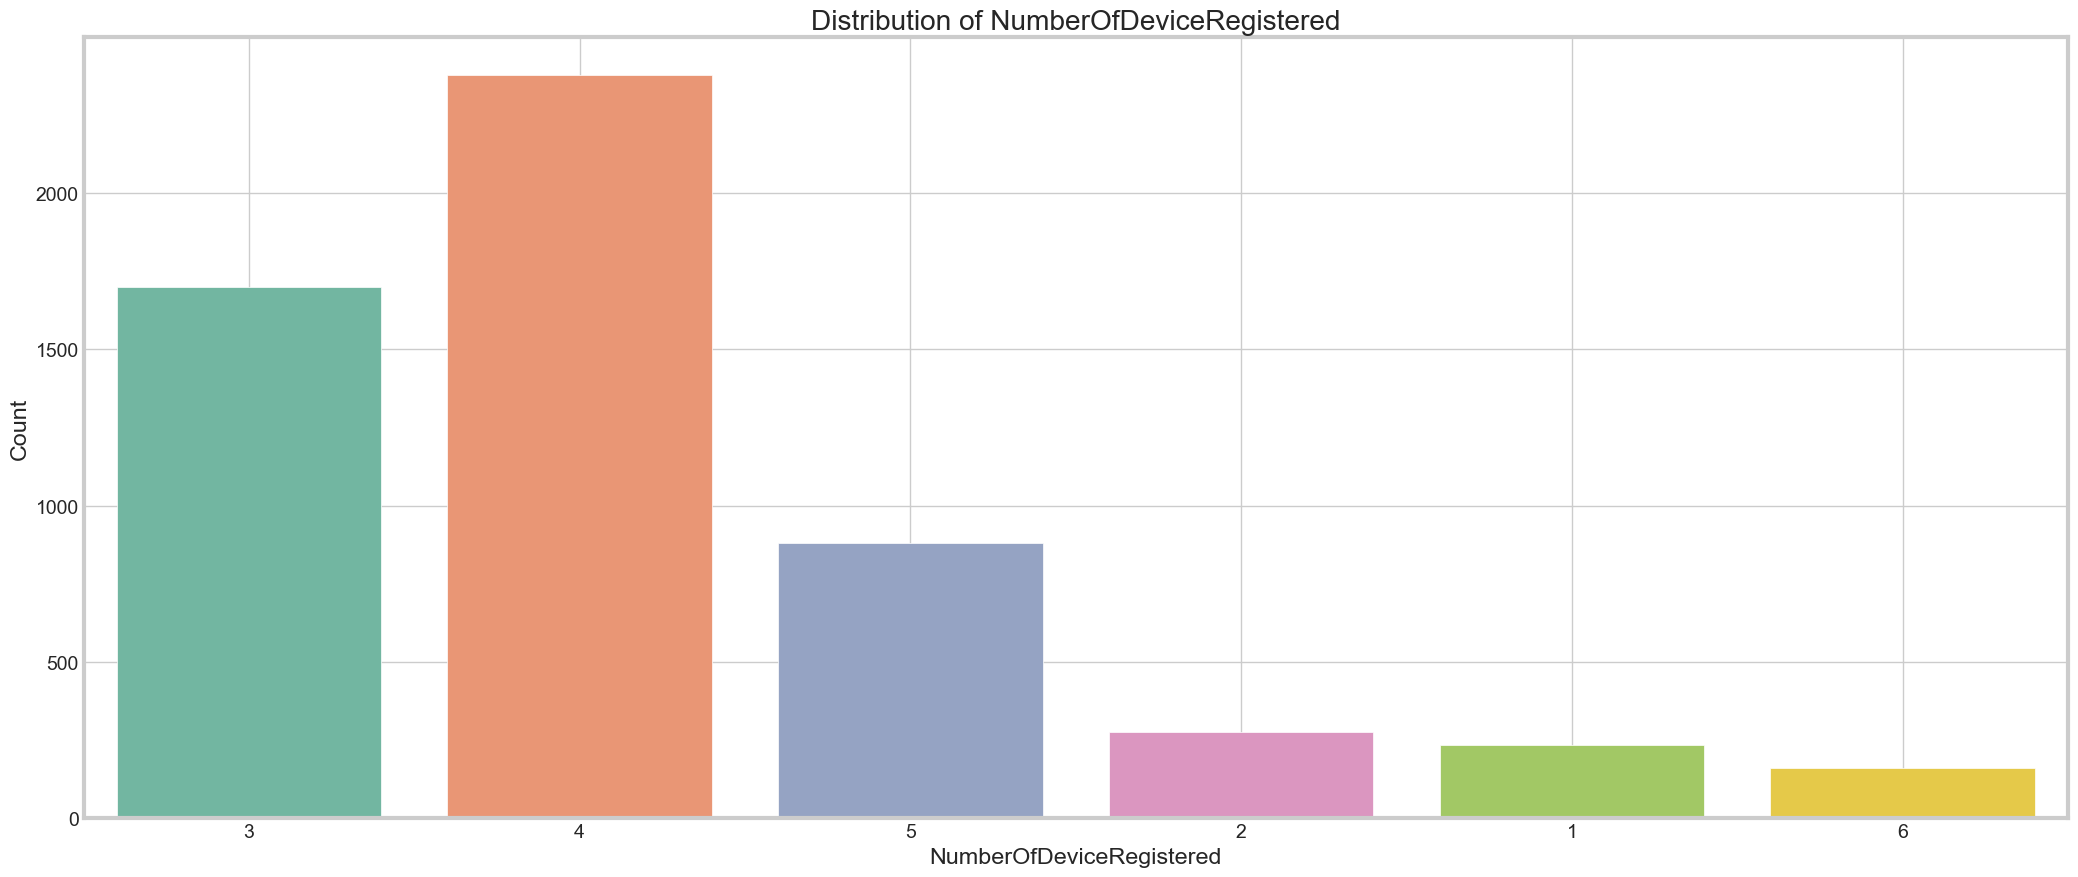

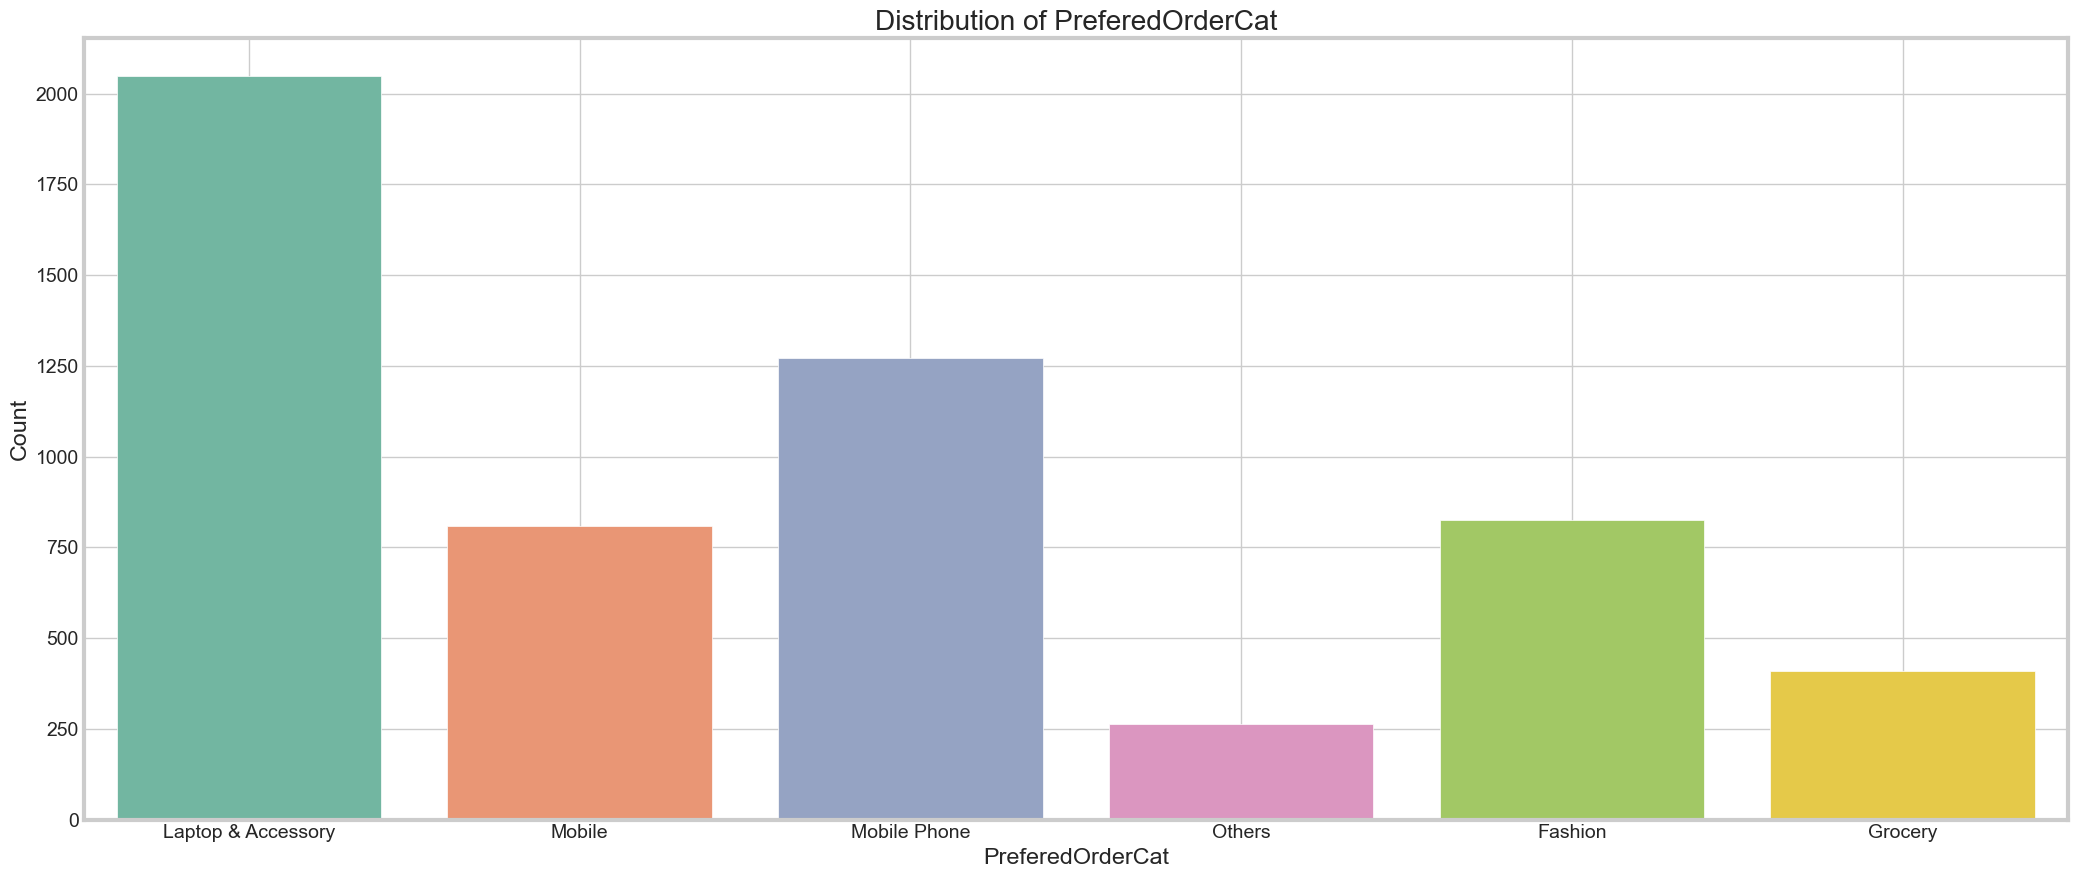

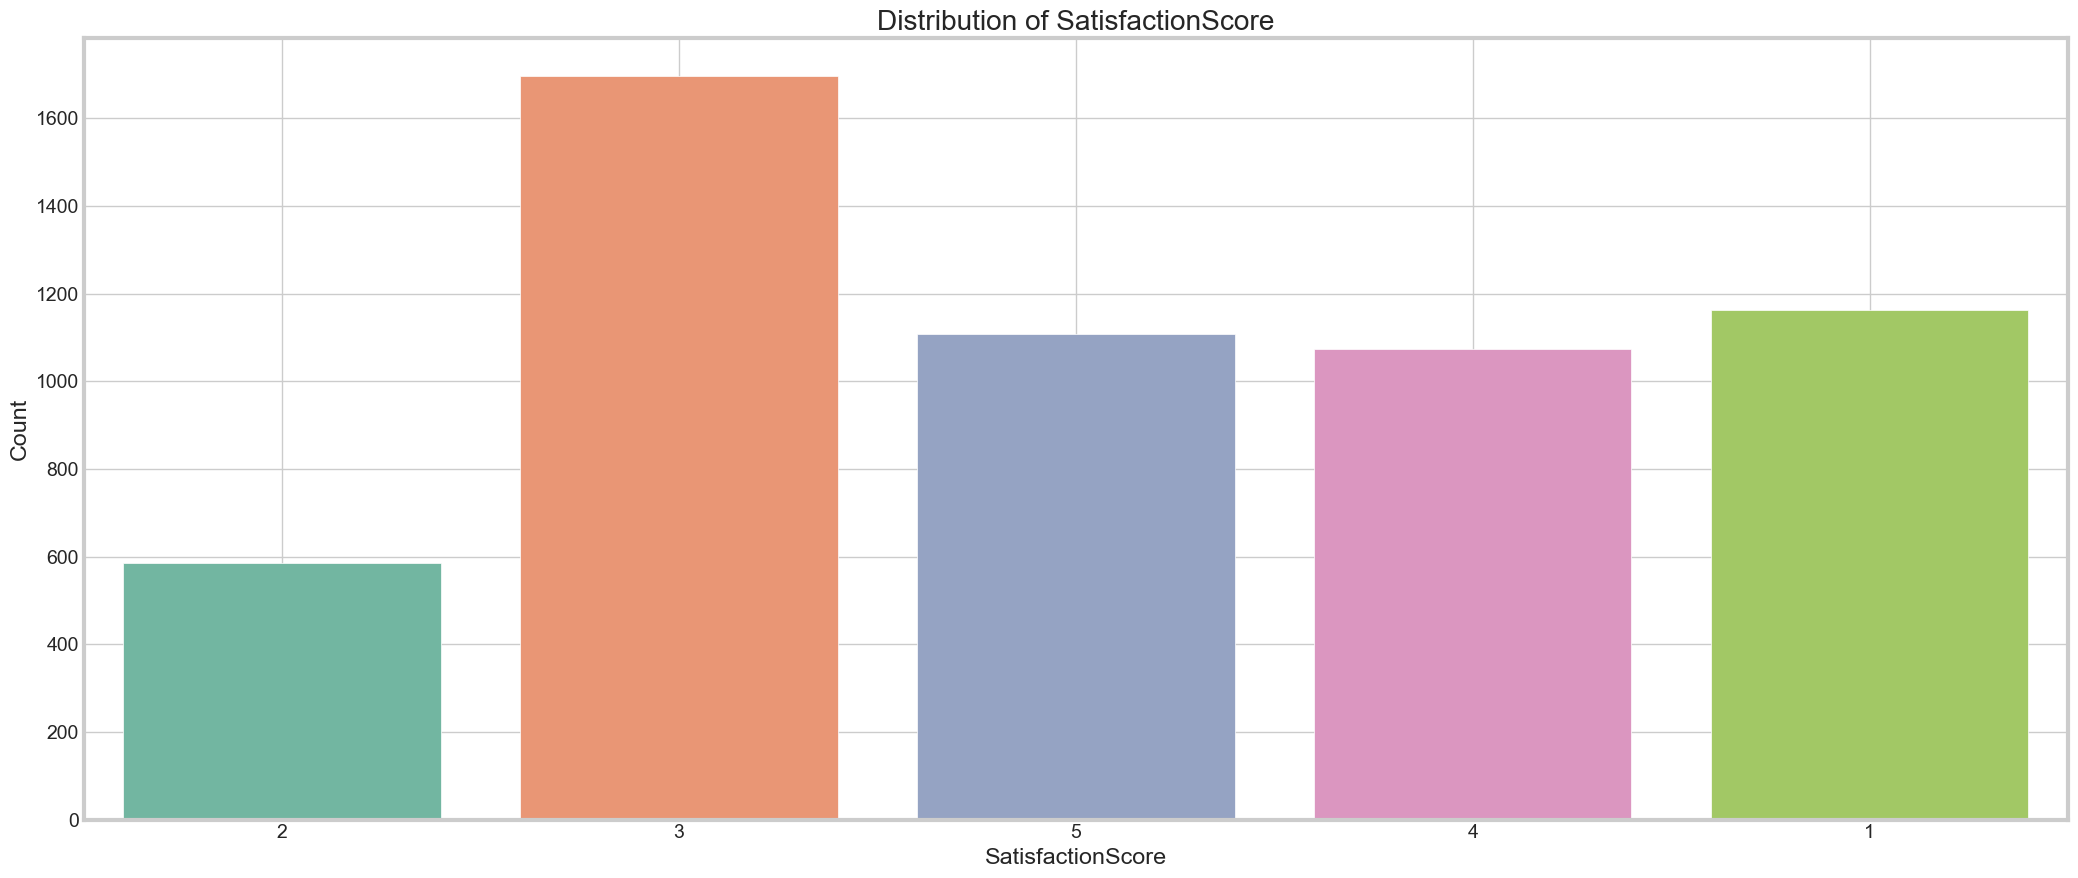

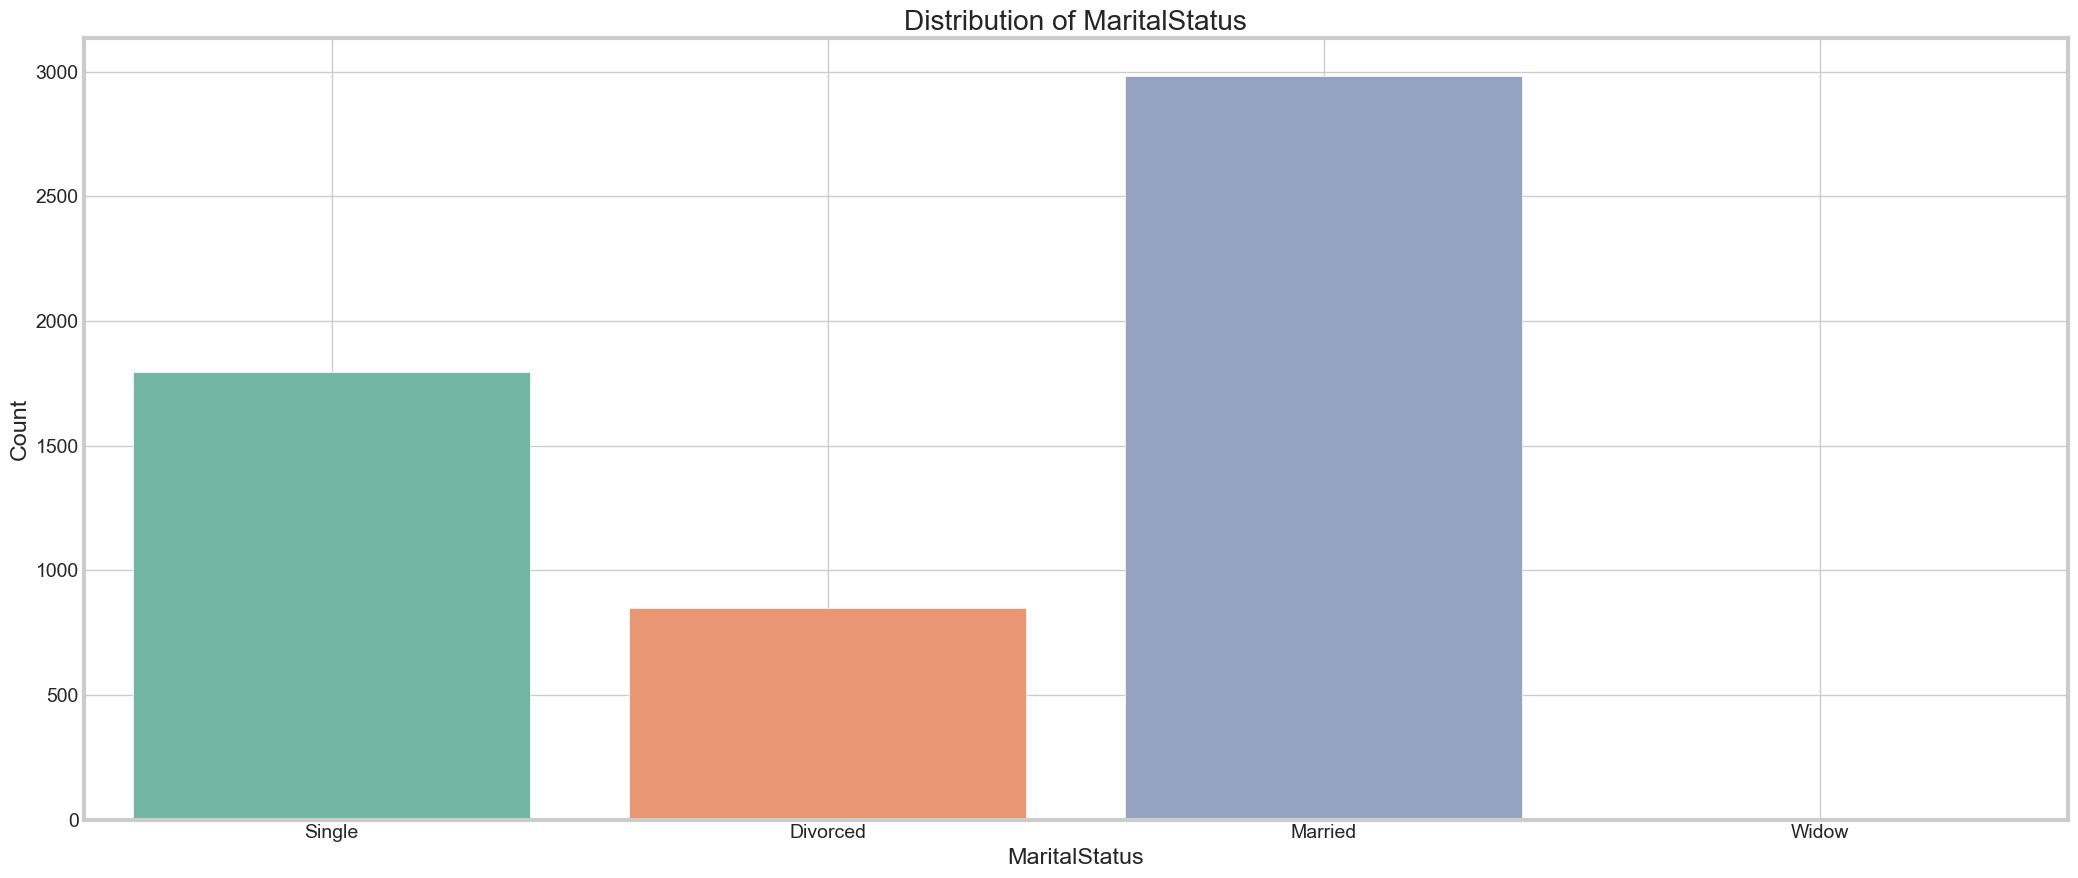

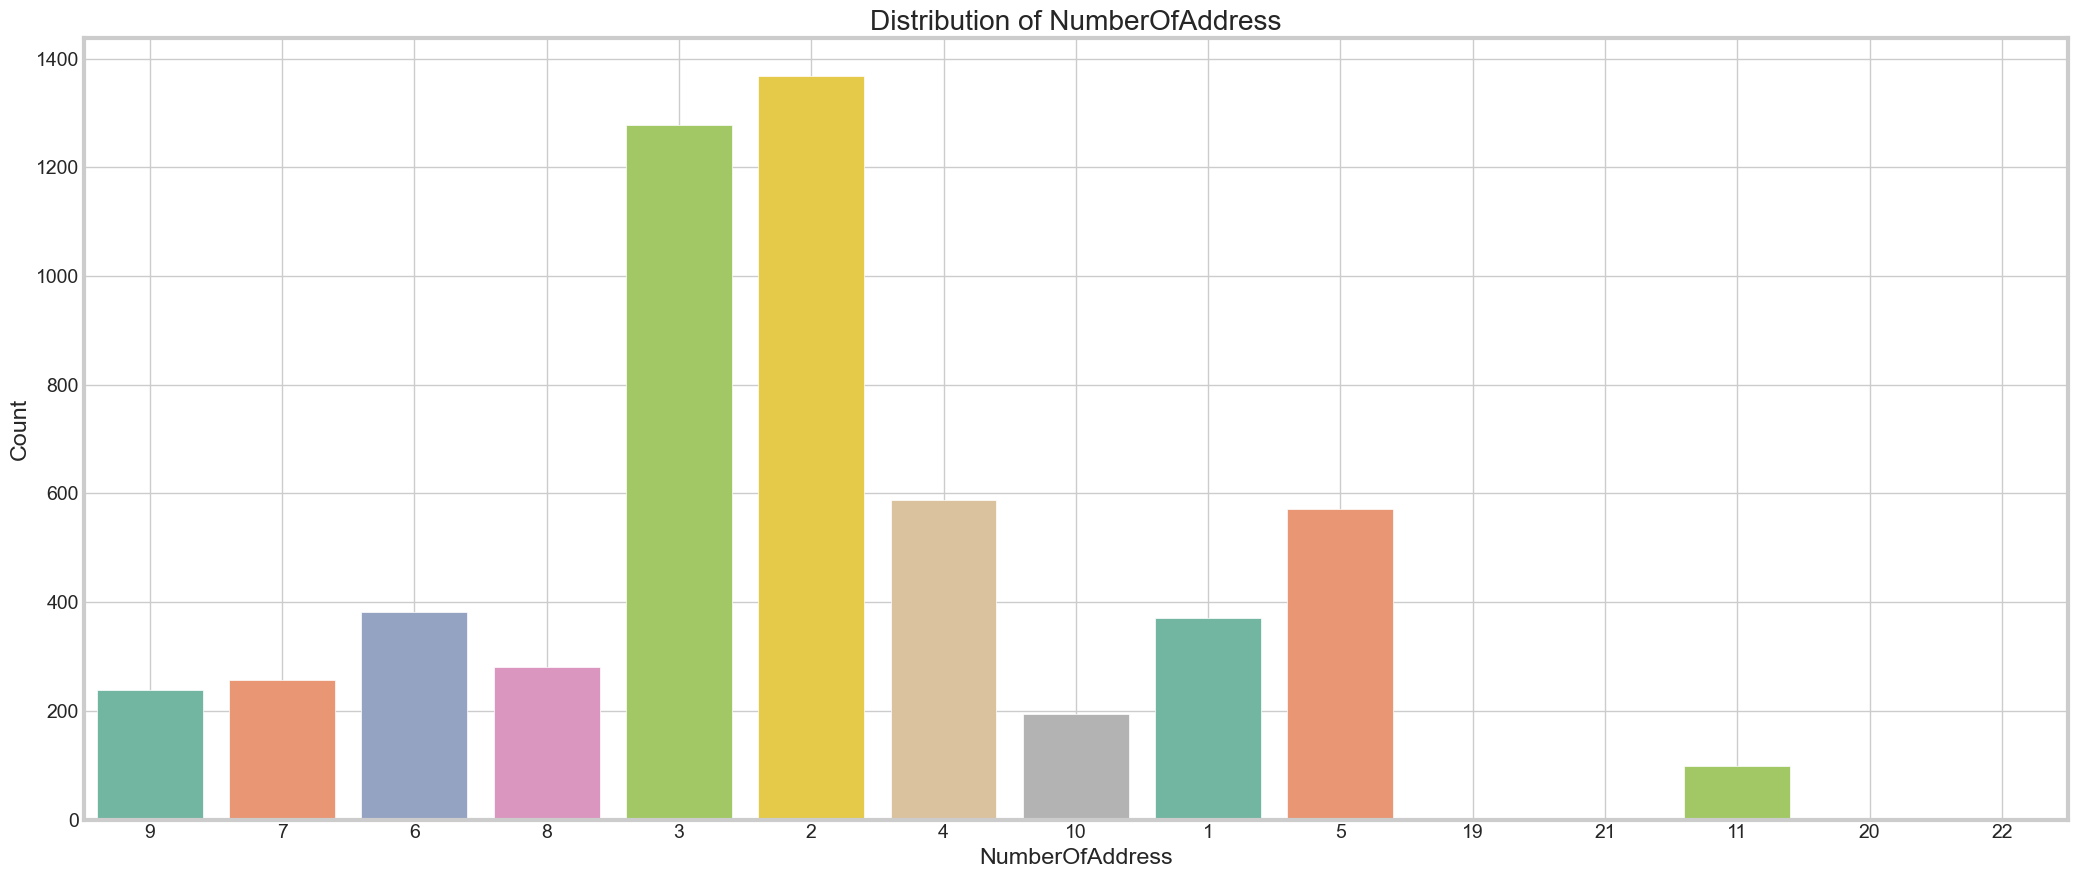

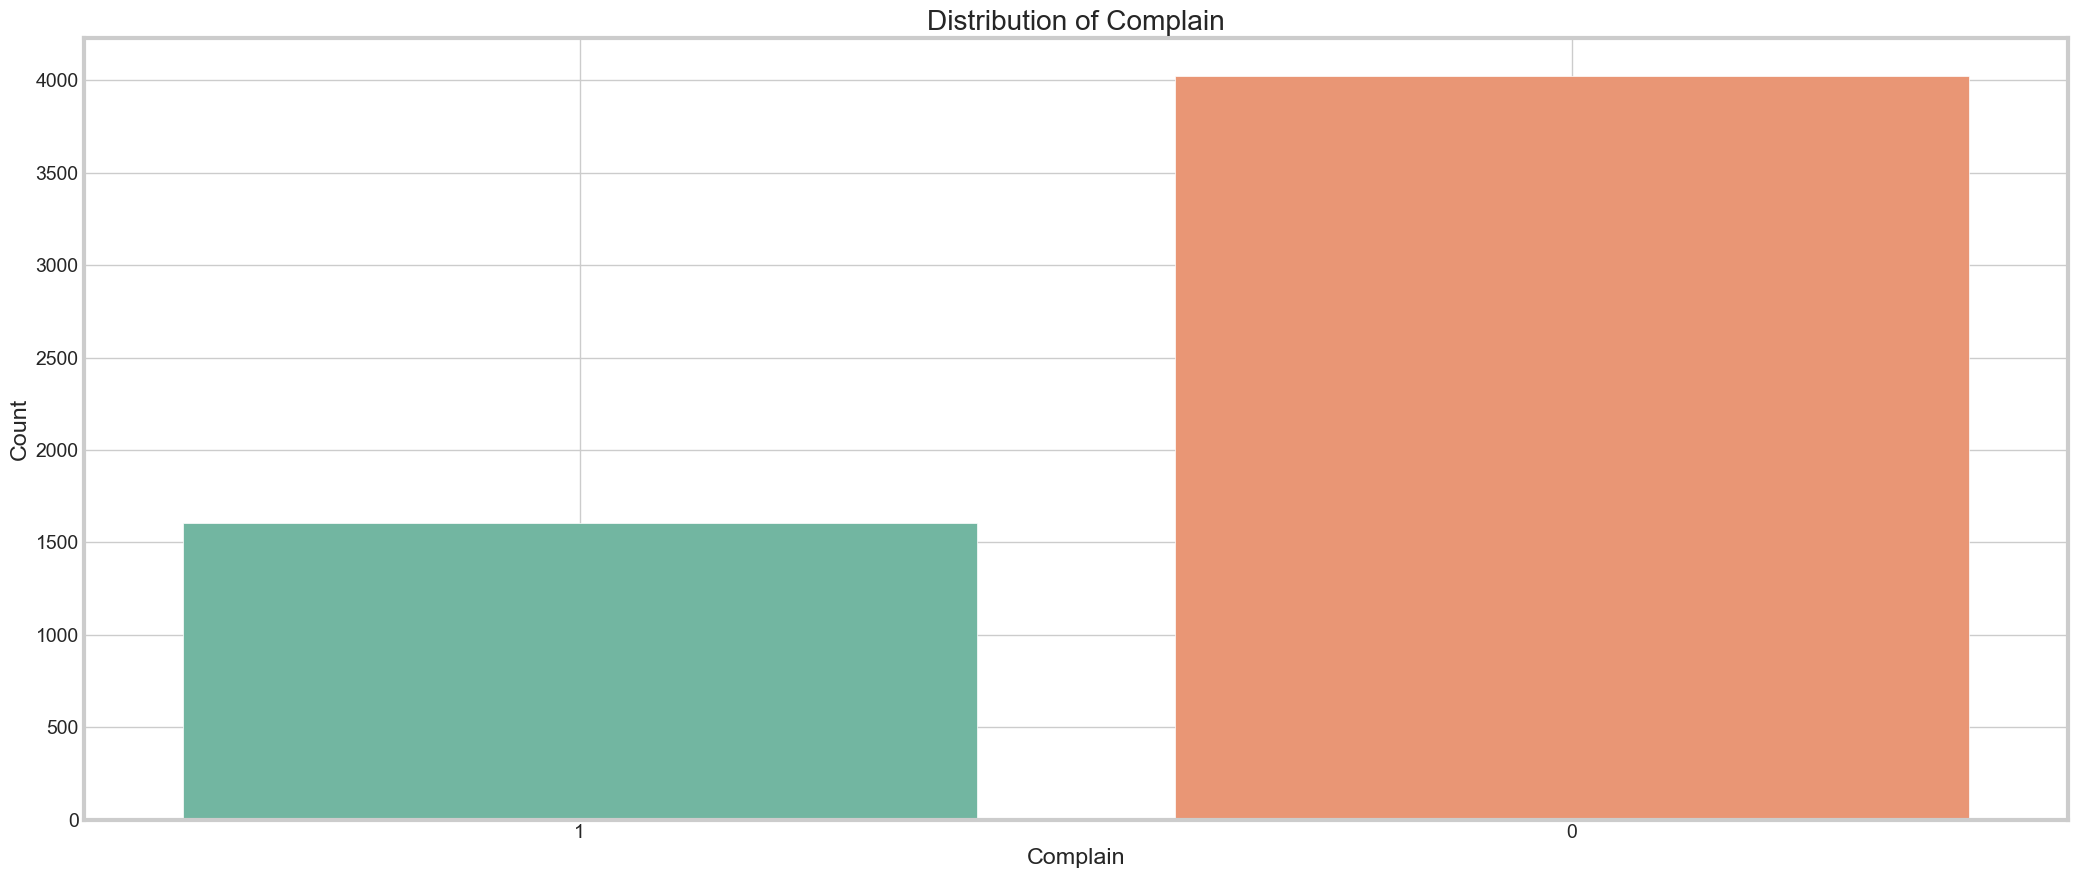

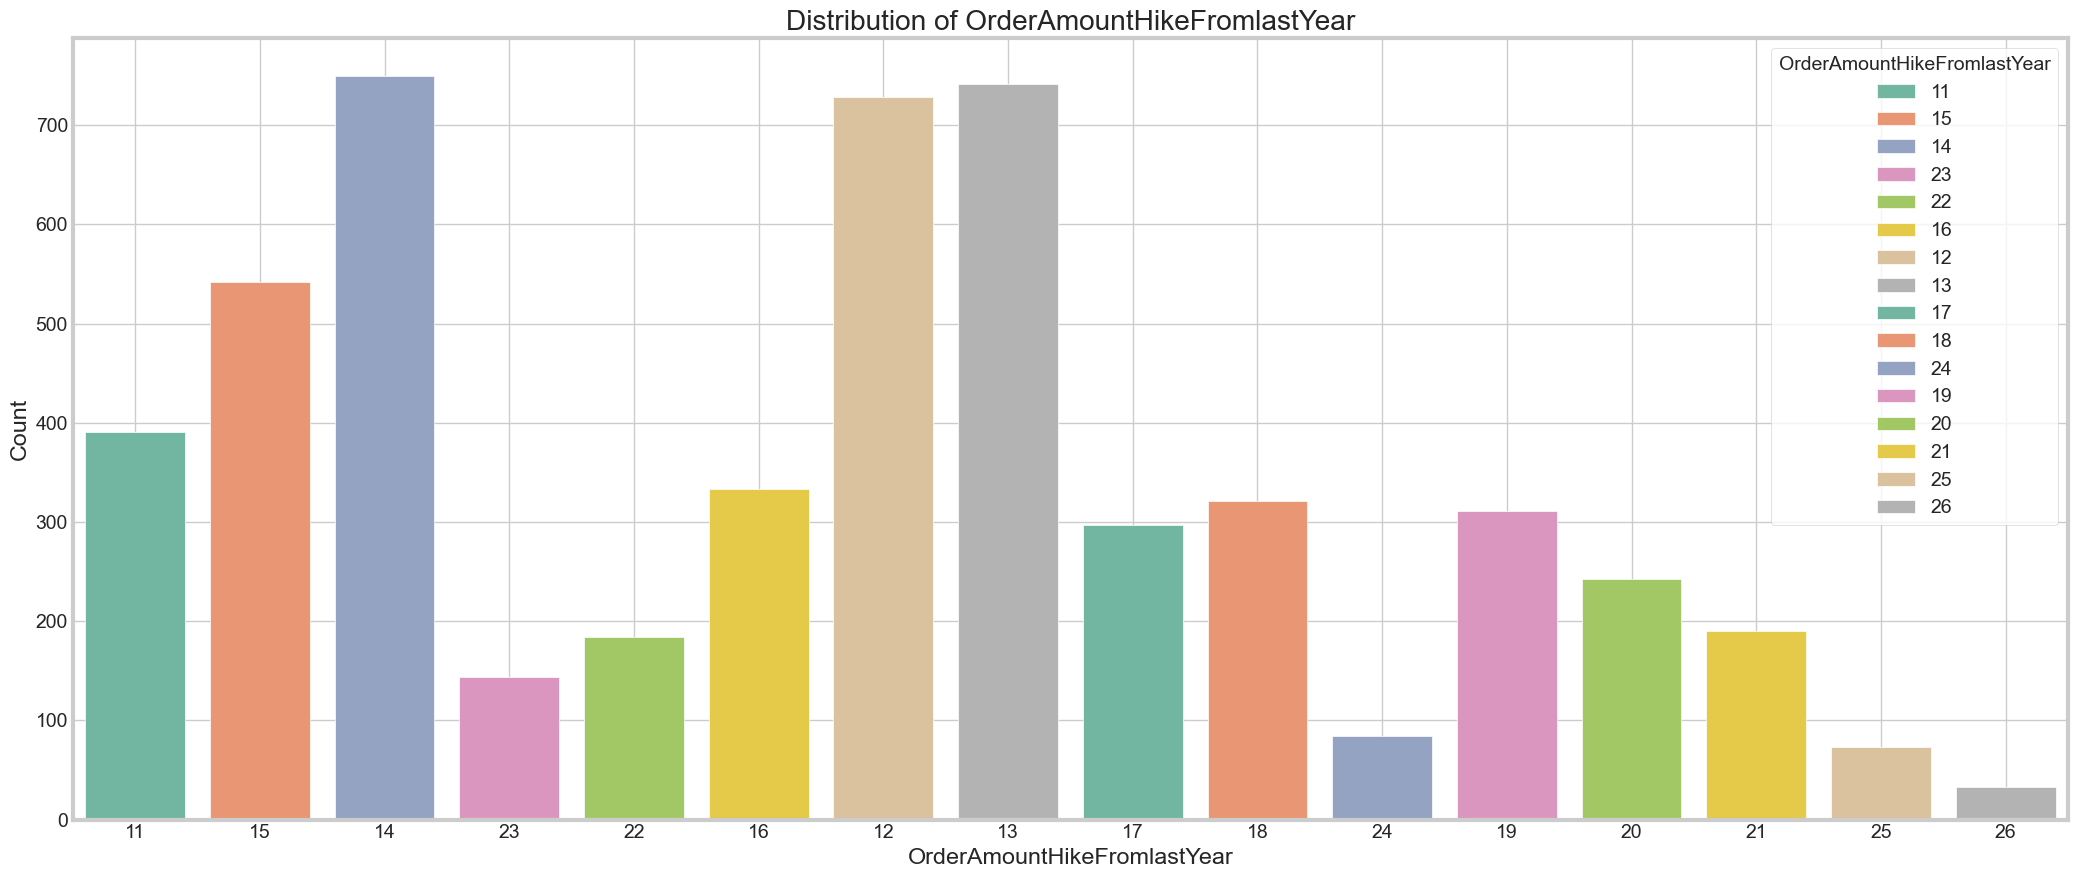

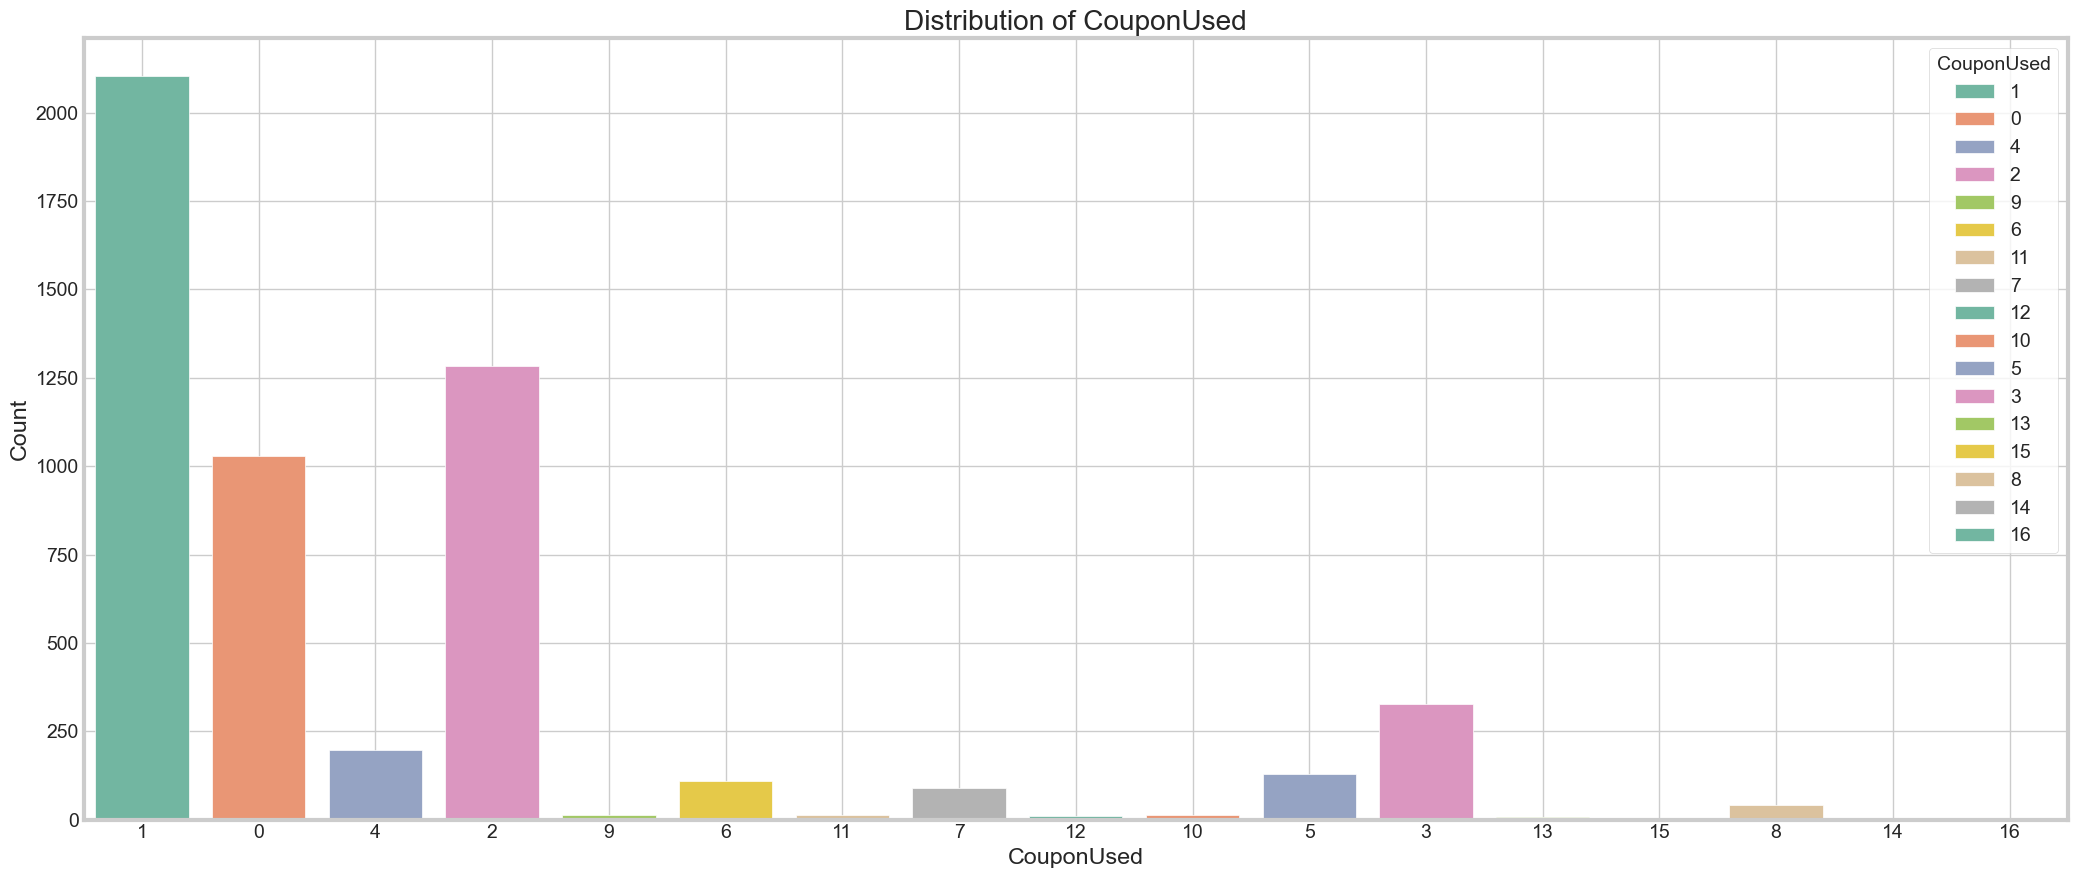

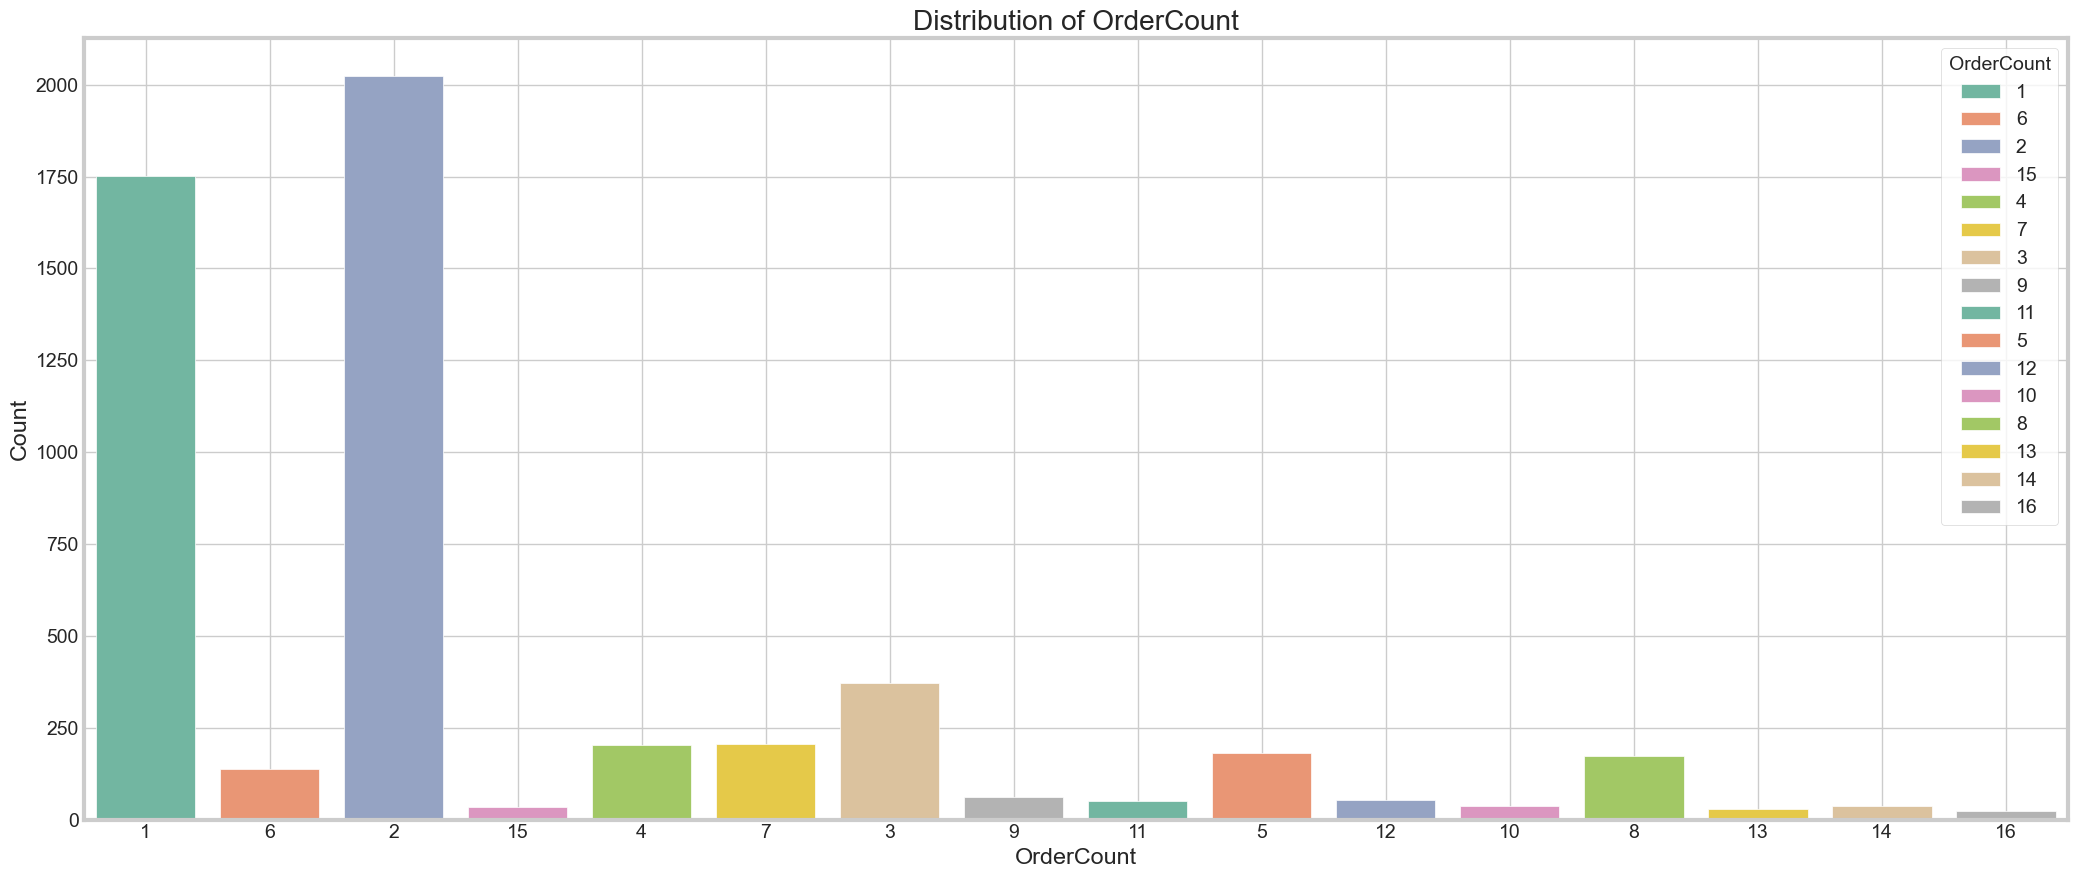

In [70]:
# Visualize the distribution of categorical features

for feature in categorical_cols:
    plt.figure(figsize=(21, 9))
    sns.countplot(x=feature, hue=feature, data=df_raw, palette='Set2')
    plt.style.use('fivethirtyeight')
    sns.set_style("whitegrid")
    plt.grid(True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')

    plt.tight_layout()
    
    plt.show()

 numerical variables and their distribution

In [71]:
for column in numerical_cols:
        print("Column: {} - Unique Values: {}".format(column, df_raw[column].unique()))
        print("="*80)

Column: Tenure - Unique Values: [ 4. nan  0. 13. 11.  9. 19. 20. 14.  8. 18.  5.  2. 30.  1. 23.  3. 29.
  6. 26. 28.  7. 24. 25. 10. 15. 22. 27. 16. 12. 21. 17. 50. 60. 31. 51.
 61.]
Column: WarehouseToHome - Unique Values: [  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  nan  10.  27.  17.  23.  33.  19.  35.  24.  16.  25.  32.
  34.   5.  21. 126.   7.  36. 127.]
Column: DaySinceLastOrder - Unique Values: [ 5.  0.  3.  7.  2.  1.  8.  6.  4. 15.  9. 11. 10. nan 13. 12. 17. 16.
 14. 30. 46. 18. 31.]
Column: CashbackAmount - Unique Values: [159.93 120.9  120.28 ... 173.77 287.91 173.78]


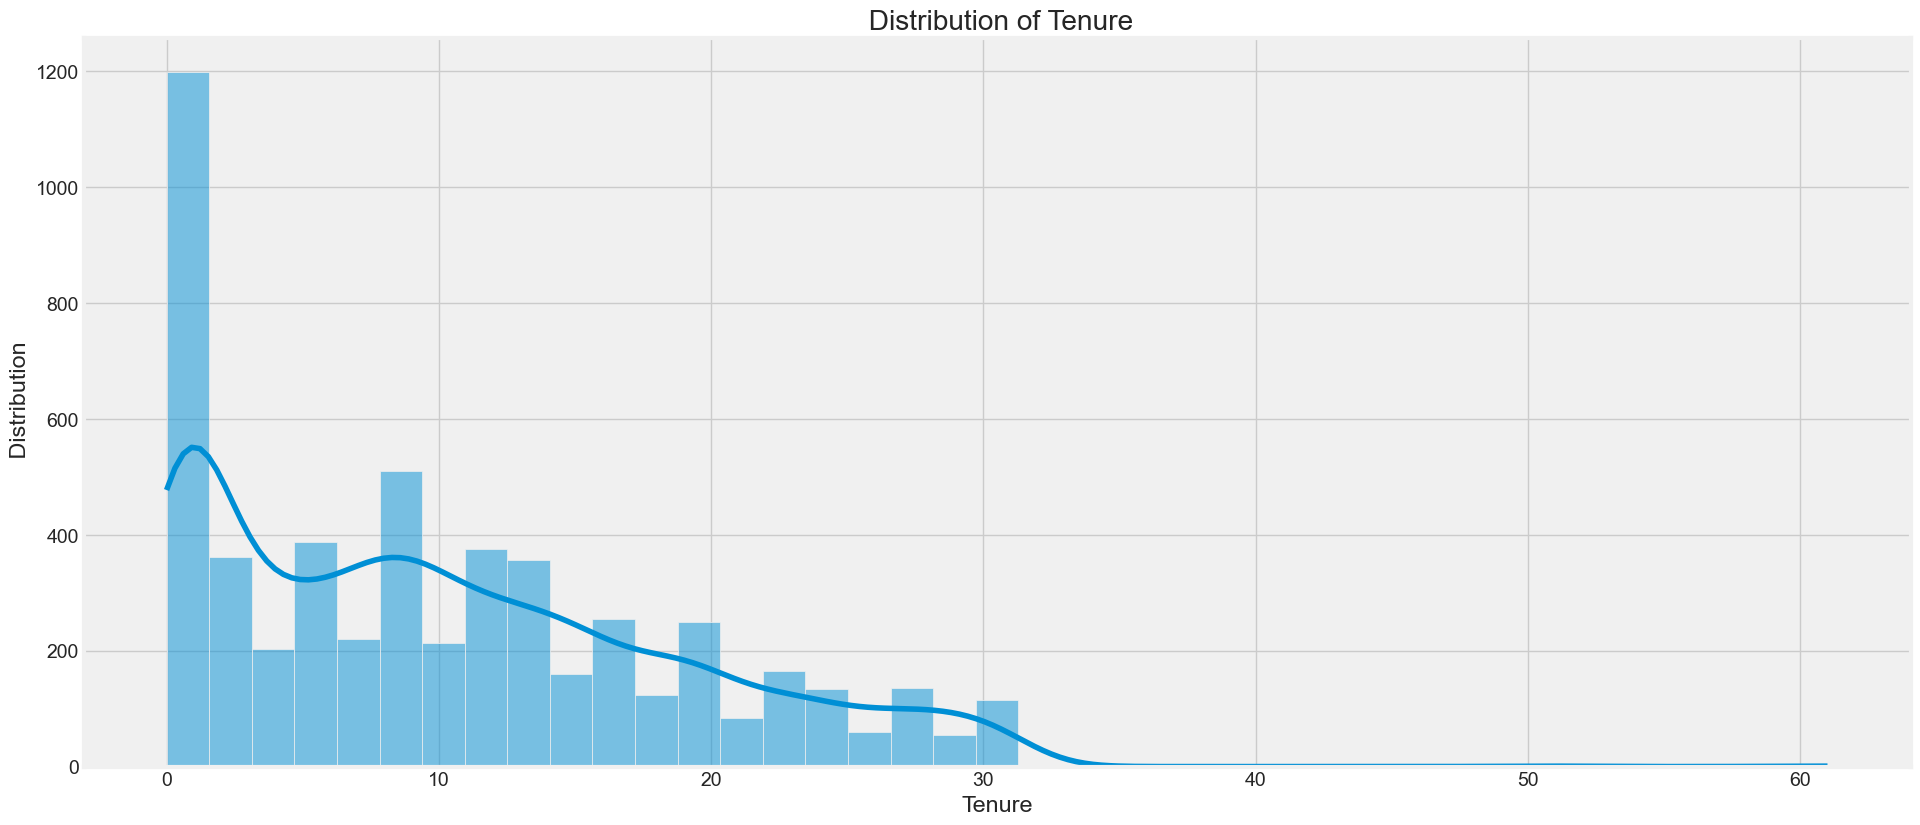

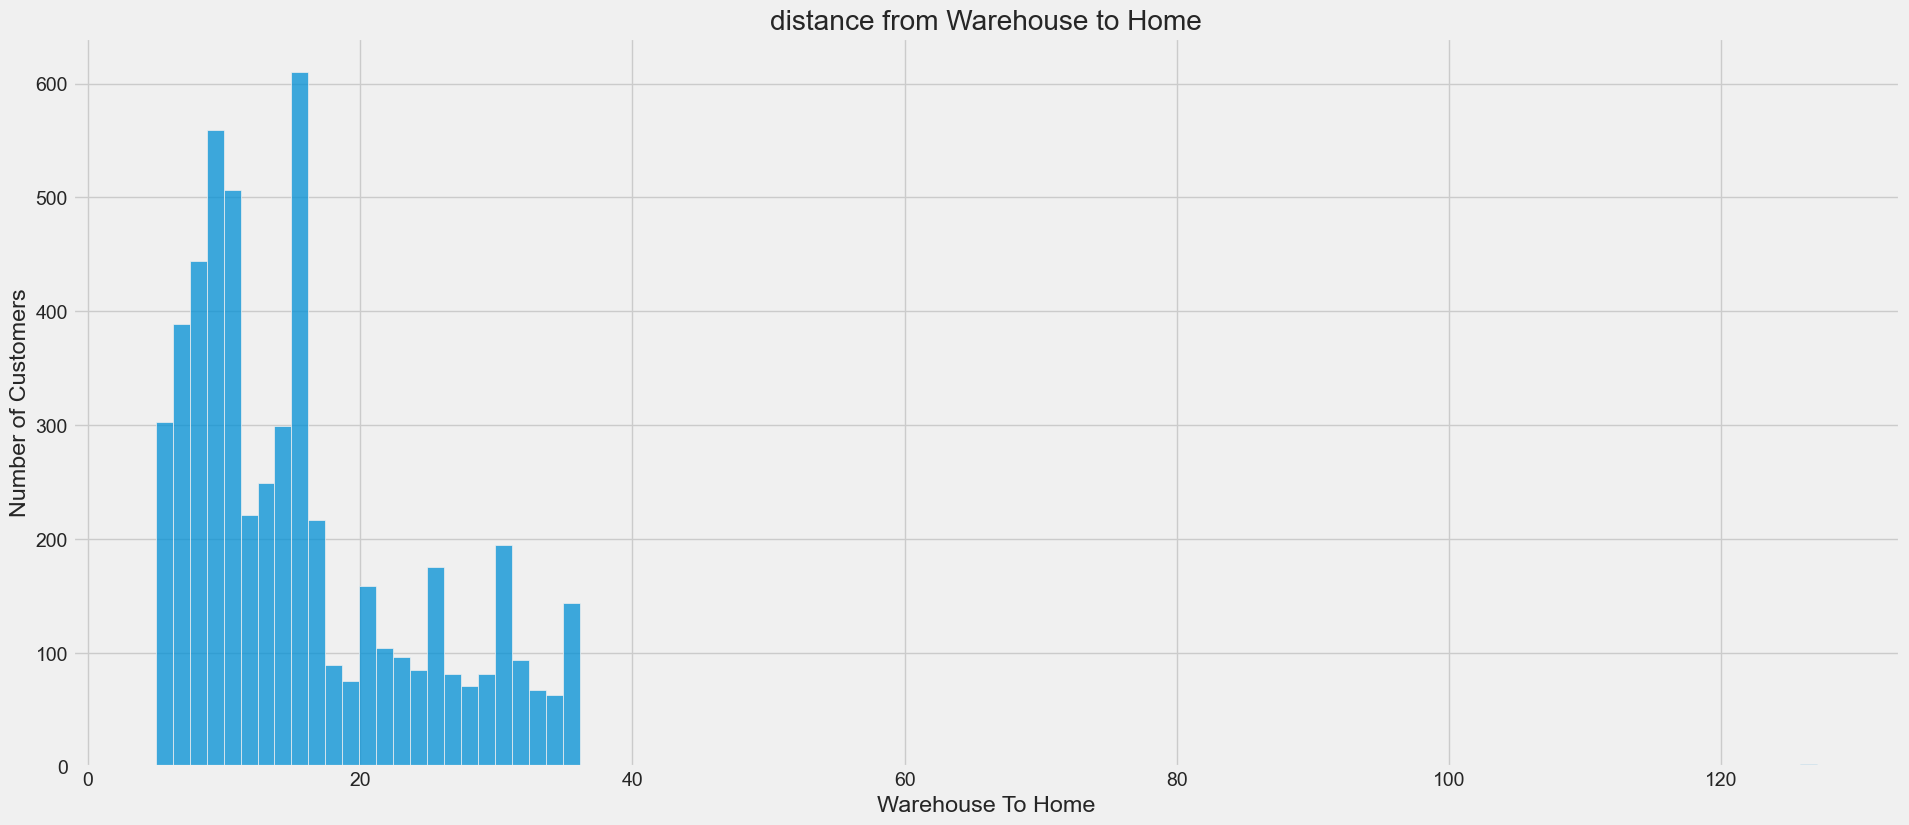

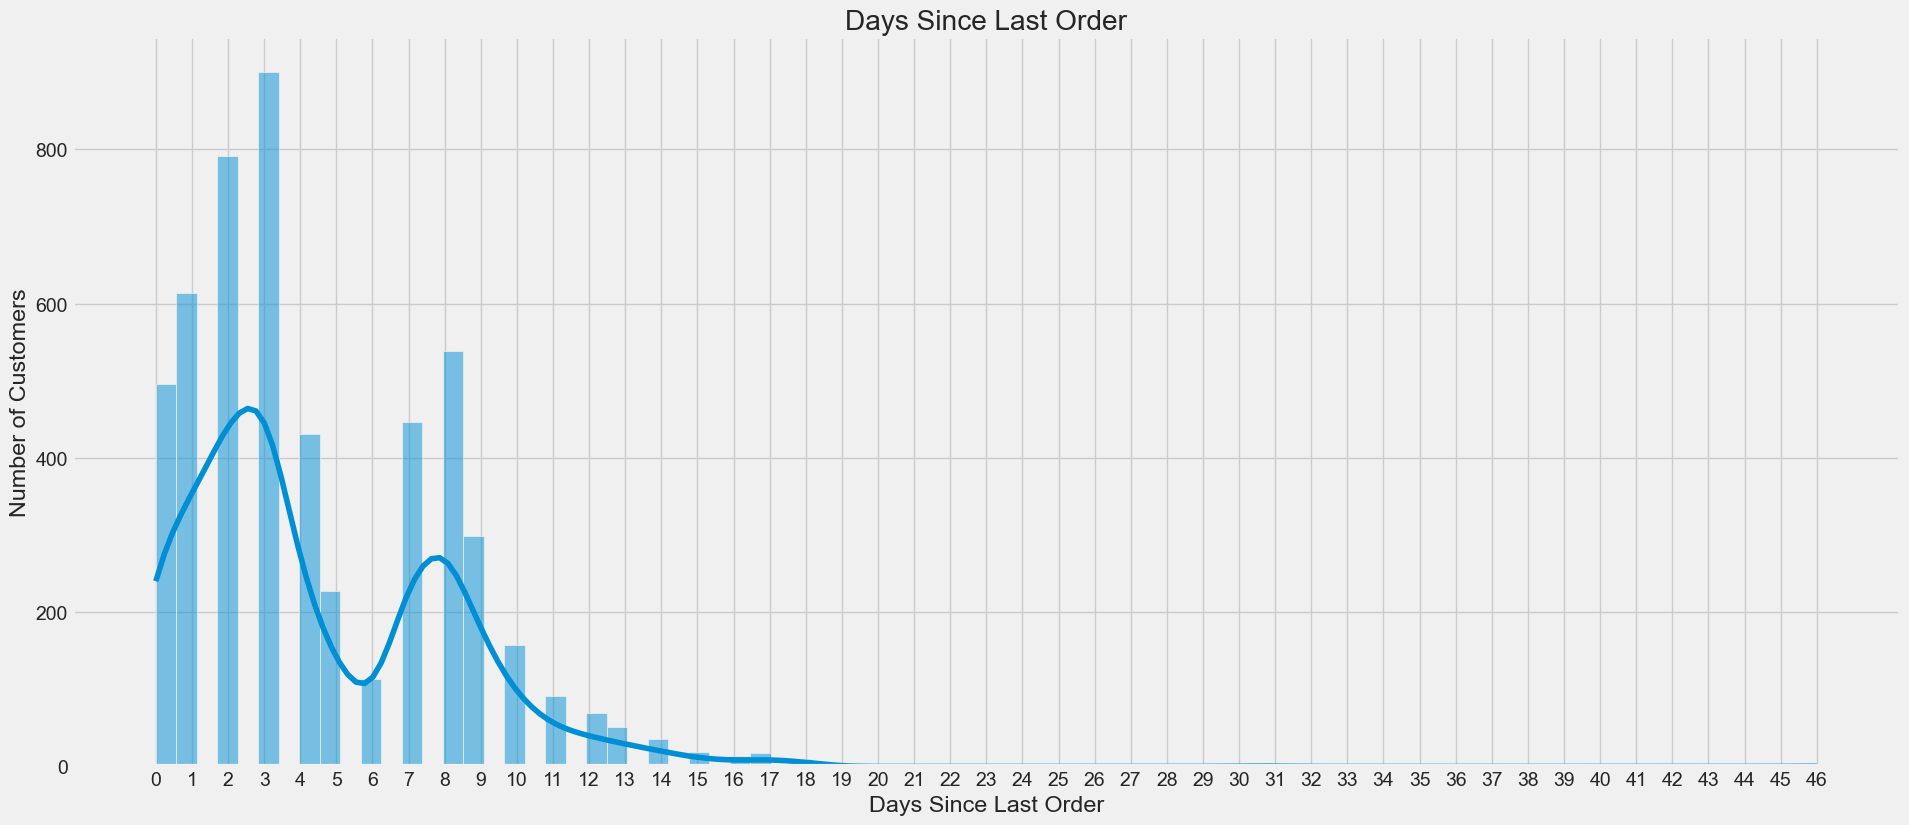

In [ ]:
# Visualize the distribution of numerical features

# Tenure
plt.figure(figsize=(21, 9))
plt.style.use('fivethirtyeight')
sns.histplot(x='Tenure', data=df_raw, kde=True)
plt.xlabel('Tenure')
plt.ylabel(' Distribution')   
plt.title(' Distribution of Tenure')
plt.show()

# warehouseToHome
plt.figure(figsize=(21, 9))
plt.style.use('fivethirtyeight')
sns.histplot(x='WarehouseToHome', data=df_raw)
plt.title('distance from Warehouse to Home')
plt.xlabel('Warehouse To Home')
plt.ylabel('Number of Customers')
plt.show()

# DaySinceLastOrder
plt.figure(figsize=(21, 9))
sns.histplot(x='DaySinceLastOrder', data=df_raw, kde=True)
plt.xticks(np.arange(0, df_raw['DaySinceLastOrder'].max() + 1, 1))
plt.style.use('fivethirtyeight')
sns.set_style("whitegrid")
plt.grid(True)
plt.title('Days Since Last Order')
plt.xlabel('Days Since Last Order')
plt.ylabel('Number of Customers')
plt.show()


In [ ]:
# Display descriptive statistics for numerical columns
df_raw[numerical_cols].describe(percentiles=[.01,.1,.25,.5,.75,.90,.95,.99]).T

,count,mean,std,min,1%,10%,25%,50%,75%,90%,95%,99%,max
Tenure,5366.0,10.189899,8.557241,0.0,0.00,1.00,2.00,9.00,16.0000,23.00,27.0000,30.0000,61.0
WarehouseToHome,5379.0,15.639896,8.531475,5.0,6.00,7.00,9.00,14.00,20.0000,30.00,33.0000,35.0000,127.0
DaySinceLastOrder,5323.0,4.543491,3.654433,0.0,0.00,1.00,2.00,3.00,7.0000,9.00,11.0000,15.0000,46.0
CashbackAmount,5630.0,532.401057,18842.837049,0.0,116.01,126.86,145.77,163.33,196.4225,259.92,291.9975,319.0194,999999.0


Text(0.5, 1.0, 'Correlation Matrix Heatmap')

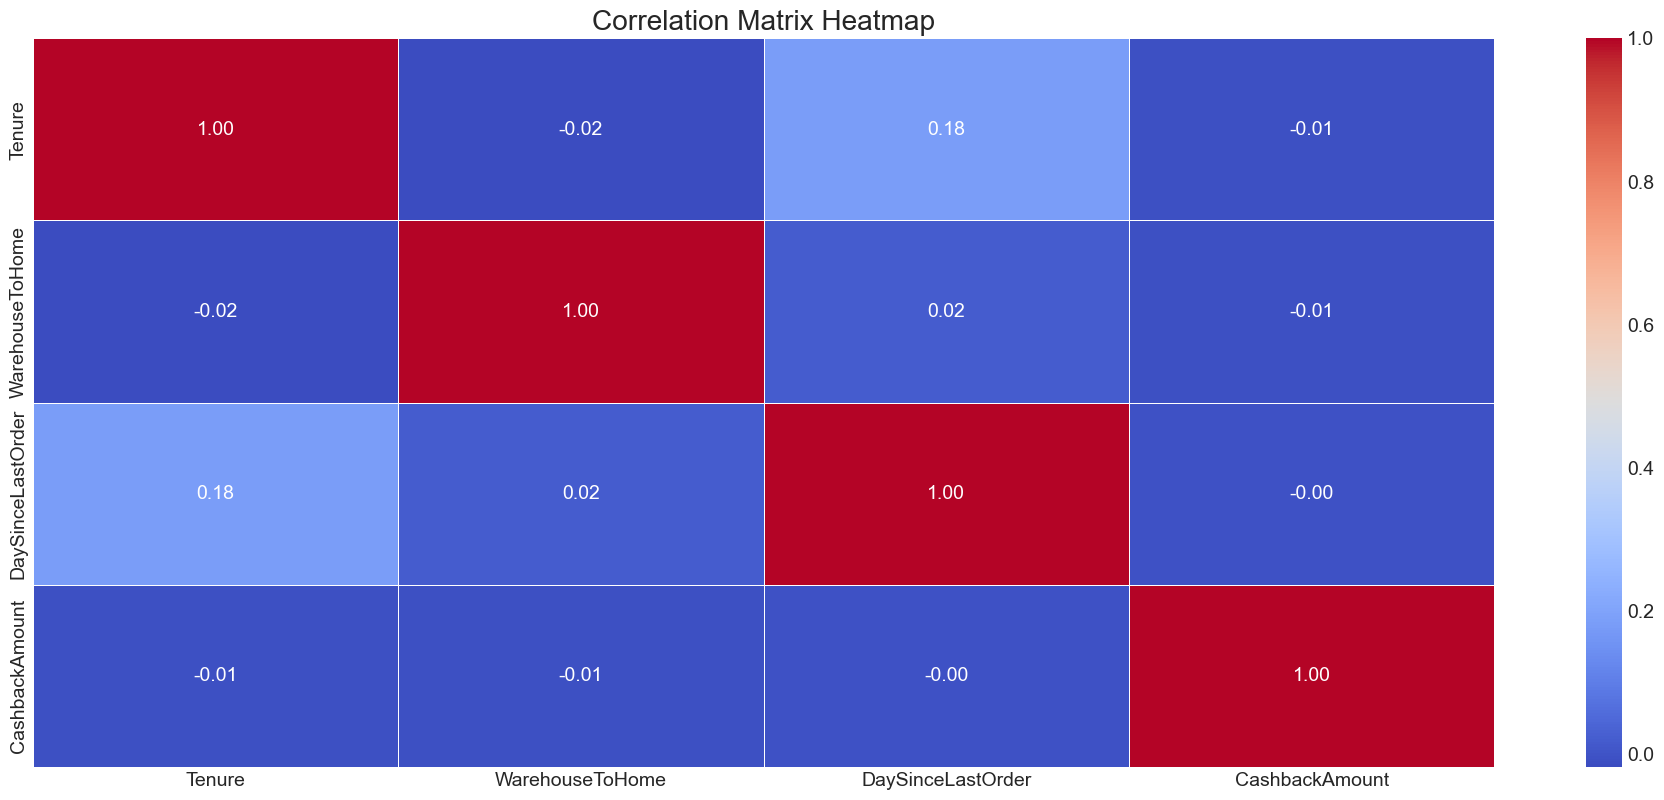

In [74]:
#heatmap of correlation matrix
plt.figure(figsize=(21, 9))
sns.heatmap(df_raw[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')

**4. Data Cleaning & Preprocessing**

In [75]:
# Introduce some NaN values to test imputation
for col in ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear',
            'CouponUsed', 'OrderCount', 'DaySinceLastOrder']:
    df_raw.loc[df_raw.sample(frac=0.05).index, col] = np.nan
    
# Create a copy of the raw DataFrame for cleaning
df_clean = df_raw.copy()


In [76]:
# Drop rows with missing essential identifiers
df_clean.dropna(subset=['CustomerID'], inplace=True)
# Drop rows with missing essential identifiers
df_clean.dropna(subset=['Gender'], inplace=True)

# Find duplicate CustomerID rows (excluding the first occurrence)
duplicates = df_clean[df_clean.duplicated('CustomerID')]
# Remove duplicate CustomerID rows, keeping the first occurrence
df_clean = df_clean.drop_duplicates(subset='CustomerID', keep='first')

# Only keep numerical columns that exist in df_clean
existing_numerical_cols = [col for col in numerical_cols if col in df_clean.columns]

In [77]:

# List of columns with missing values to impute
cols_to_impute = [
    'HourSpendOnApp','OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount'
]

# Impute  columns with mean
imputer = SimpleImputer(strategy='mean')
df_clean[cols_to_impute] = imputer.fit_transform(df_clean[cols_to_impute])

# Impute numerical values with median
imputer_median = SimpleImputer(strategy='median')
df_clean['Tenure'] = imputer_median.fit_transform(df_clean[['Tenure']])
df_clean['WarehouseToHome'] = imputer_median.fit_transform(df_clean[['WarehouseToHome']])
df_clean['DaySinceLastOrder'] = imputer_median.fit_transform(df_clean[['DaySinceLastOrder']])   



In [78]:
df_clean.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [79]:
# Save the cleaned DataFrame to an Excel file
df_clean.to_excel("cleaned_data.xlsx", index=False)

In [ ]:
# Display the shape of the cleaned DataFrame
df_clean.shape

(5626, 20)

**5.Model Selection and Trainning**

In [ ]:
# Prepare the data for modeling
df_clean.drop(columns=['CustomerID'], inplace=True)
y = df_clean['Churn']
X = df_clean.drop(columns=['Churn'])

In [ ]:
#split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [83]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4500 entries, 559 to 4407
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Tenure                       4500 non-null   float64
 1   PreferredLoginDevice         4500 non-null   object 
 2   CityTier                     4500 non-null   object 
 3   WarehouseToHome              4500 non-null   float64
 4   PreferredPaymentMode         4500 non-null   object 
 5   Gender                       4500 non-null   object 
 6   HourSpendOnApp               4500 non-null   float64
 7   NumberOfDeviceRegistered     4500 non-null   object 
 8   PreferedOrderCat             4500 non-null   object 
 9   SatisfactionScore            4500 non-null   object 
 10  MaritalStatus                4500 non-null   object 
 11  NumberOfAddress              4500 non-null   object 
 12  Complain                     4500 non-null   object 
 13  OrderAmountHikeFromla

In [84]:
train_categorical_cols = (X_train.dtypes[X_train.dtypes == 'object'].index)

In [85]:
train_categorical_cols

Index(['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain'],
      dtype='object')

In [86]:
for col in categorical_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype("category")

In [87]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4500 entries, 559 to 4407
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Tenure                       4500 non-null   float64 
 1   PreferredLoginDevice         4500 non-null   category
 2   CityTier                     4500 non-null   category
 3   WarehouseToHome              4500 non-null   float64 
 4   PreferredPaymentMode         4500 non-null   category
 5   Gender                       4500 non-null   category
 6   HourSpendOnApp               4500 non-null   category
 7   NumberOfDeviceRegistered     4500 non-null   category
 8   PreferedOrderCat             4500 non-null   category
 9   SatisfactionScore            4500 non-null   category
 10  MaritalStatus                4500 non-null   category
 11  NumberOfAddress              4500 non-null   category
 12  Complain                     4500 non-null   category
 13  OrderA

**6. Hyperparameter Tuning **

In [ ]:
# Install hyperopt for hyperparameter optimization
%pip install hyperopt

import xgboost as xgb
from hyperopt import STATUS_OK, Trials, fmin, tpe
from hyperopt.pyll.stochastic import sample

train_dmatrix = xgb.DMatrix(data=X_train, label=y_train, enable_categorical=True)

N_FOLDS = 10

def objective(params, n_folds = N_FOLDS):
    params['objective'] = 'binary:logistic'

    # Perform cross-validation: cv_results
    cv_results = xgb.cv(
        dtrain=train_dmatrix,
        params=params,
        nfold=n_folds,
        num_boost_round=10000,
        early_stopping_rounds=100, 
        metrics="auc",
        as_pandas=True,
        seed=42
    )

    # Print the metrics
    loss = 1 - cv_results["test-auc-mean"].iloc[-1]
    n_estimators = cv_results["test-auc-mean"].idxmax() + 1
    return {'loss': loss, 'params': params, 'n_estimators': n_estimators, 'status': STATUS_OK}

Note: you may need to restart the kernel to use updated packages.


In [89]:
from hyperopt import hp

hyperparameter_space = {
    'n_jobs': -1,
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 0.8),
    'subsample': hp.uniform('subsample', 0.6, 0.8),
    'min_child_weight': hp.quniform('min_child_weight', 1, 7, 2),
    'reg_alpha': hp.uniform('reg_alpha', 0.0, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 0.0, 1.0),
    'max_depth': hp.randint('max_depth', 1,16),
    'gamma': hp.uniform('gamma', 0.1,0.4),
    'max_delta_step': hp.randint('max_delta_step',0,10),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2))
}

In [90]:
bayes_trials = Trials()

In [91]:
MAX_EVALS = 15

best = fmin(fn = objective, space = hyperparameter_space, algo = tpe.suggest, max_evals = MAX_EVALS, trials = bayes_trials)

100%|██████████| 15/15 [09:23<00:00, 37.53s/trial, best loss: 0.028045842742532634]


In [92]:
best

{'colsample_bytree': np.float64(0.6731817309755151),
 'gamma': np.float64(0.2524581661583132),
 'learning_rate': np.float64(0.011566792202111171),
 'max_delta_step': np.int64(6),
 'max_depth': np.int64(10),
 'min_child_weight': np.float64(2.0),
 'reg_alpha': np.float64(0.9405746433362295),
 'reg_lambda': np.float64(0.32015581476869537),
 'subsample': np.float64(0.7369559069902027)}

In [93]:
{'colsample_bytree': 0.7471550423847237,
 'gamma': 0.1877601195322839,
 'learning_rate': 0.02619420538520094,
 'max_delta_step': 7,
 'max_depth': 1,
 'min_child_weight': 4.0,
 'reg_alpha': 0.7434367306311531,
 'reg_lambda': 0.7050040171862231,
 'subsample': 0.6437975746430178}

{'colsample_bytree': 0.7471550423847237,
 'gamma': 0.1877601195322839,
 'learning_rate': 0.02619420538520094,
 'max_delta_step': 7,
 'max_depth': 1,
 'min_child_weight': 4.0,
 'reg_alpha': 0.7434367306311531,
 'reg_lambda': 0.7050040171862231,
 'subsample': 0.6437975746430178}

In [94]:
# Ensure y_train is integer type for XGBoost
y_train_int = y_train.astype(int)

xgb_best = xgb.XGBClassifier(**best, tree_method="hist", enable_categorical=True)

xgb_best.fit(X_train, y_train_int)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,np.float64(0.6731817309755151)
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [95]:
for col in categorical_cols:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype("category")

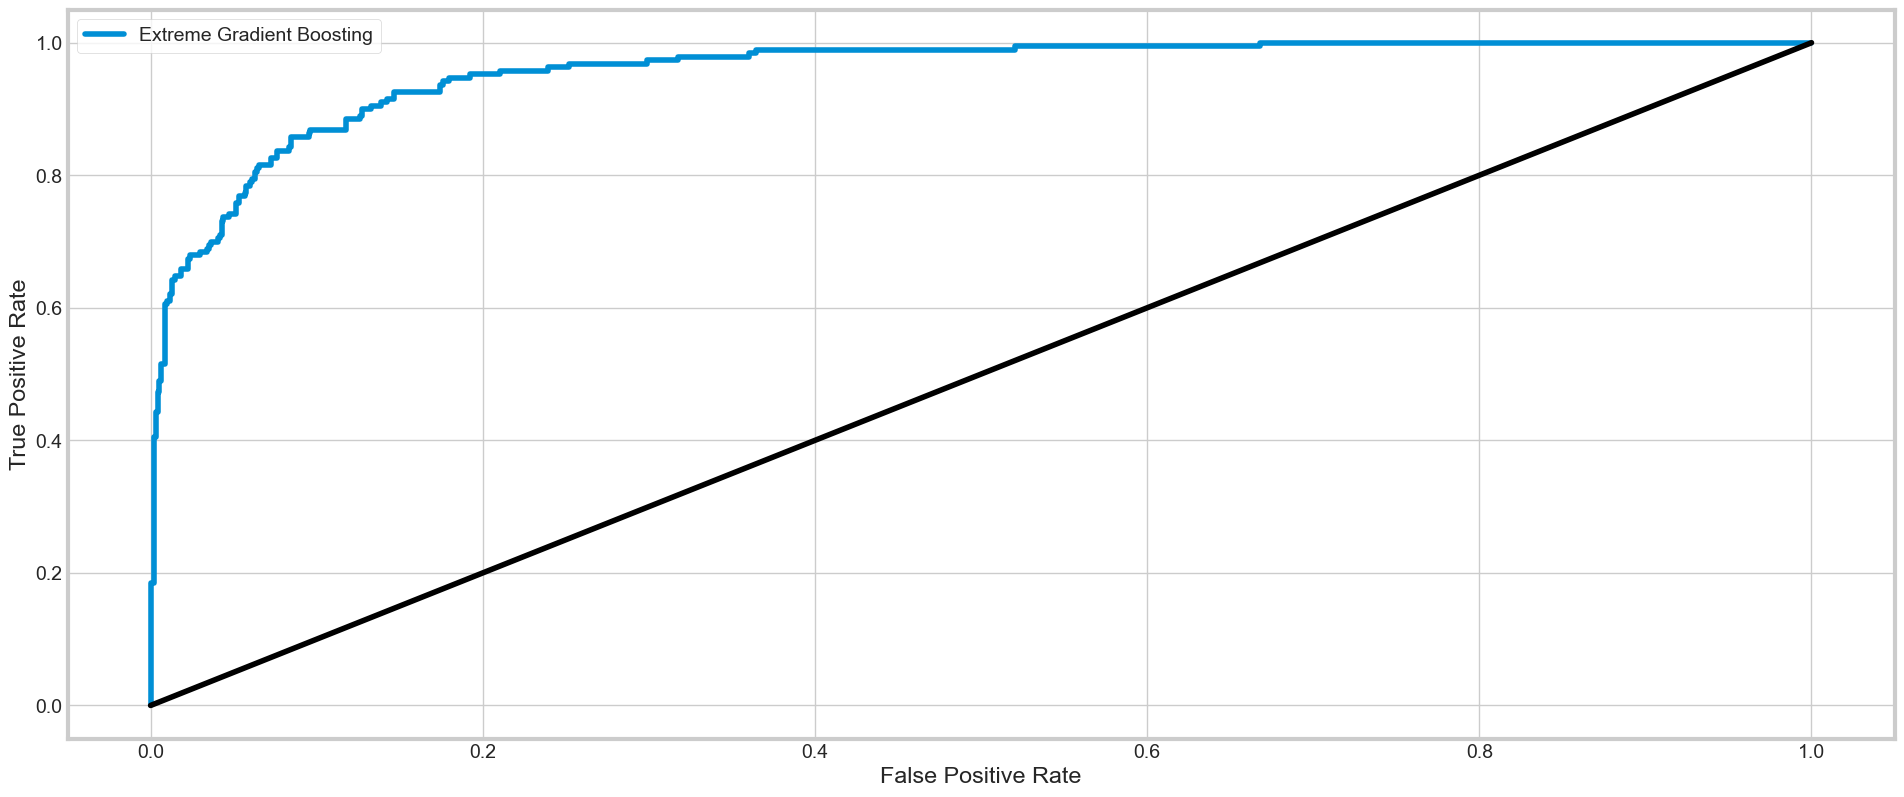

In [ ]:
# Evaluate XGBoost model on the test set
from sklearn.metrics import roc_curve, accuracy_score, roc_auc_score, recall_score, precision_score

def add_roc_plot(model, test_x, test_y, legend_text):
    # Convert y_test to integers if they are strings
    y_true = test_y.astype(int) if test_y.dtype == object else test_y
    y_pred_prob = model.predict_proba(test_x)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    plt.plot(fpr, tpr, label=legend_text)
    plt.legend()

models_list = [xgb_best]
model_names = ['Extreme Gradient Boosting']

plt.figure(figsize=(21, 9))
[add_roc_plot(model, X_test, y_test, legend_text) for model, legend_text in zip(models_list, model_names)]

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot([0, 1], [0, 1], "k-")
plt.show()

In [97]:
list_scores = [roc_auc_score, recall_score, precision_score, accuracy_score]
calc_scores = []

def compute_scores(model, x_test, y_test, scores):
    # Ensure y_test is integer type for all metrics
    y_test_int = y_test.astype(int) if y_test.dtype == object else y_test
    return [round(score(y_test_int, model.predict(x_test)), 2) for score in scores]
    
[calc_scores.append(compute_scores(model, X_test, y_test, list_scores)) for model in models_list] 

score_names = ['roc_auc', 'recall', 'precision', 'accuracy']
scores_df = pd.DataFrame(calc_scores, columns=score_names, index=model_names)

scores_df

,roc_auc,recall,precision,accuracy
Extreme Gradient Boosting,0.59,0.18,0.97,0.86


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

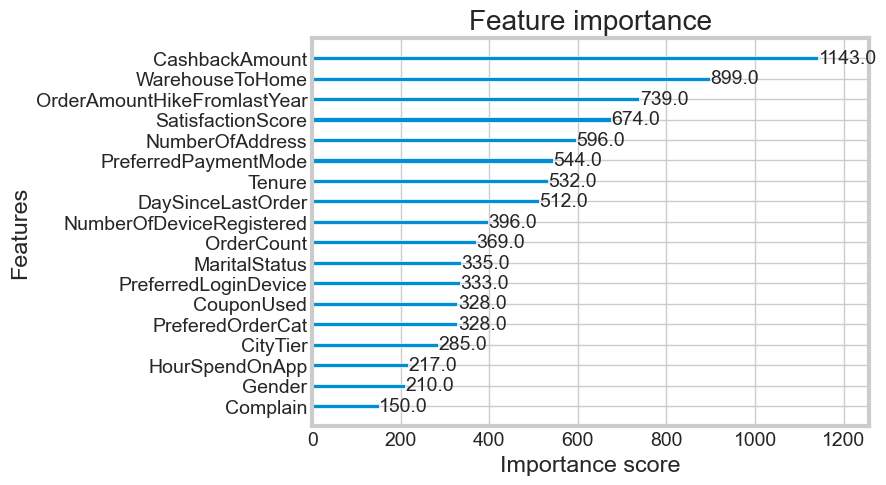

In [ ]:
# Plot feature importance for the best XGBoost model
xgb.plot_importance(xgb_best)

In [99]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4500 entries, 559 to 4407
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Tenure                       4500 non-null   float64 
 1   PreferredLoginDevice         4500 non-null   category
 2   CityTier                     4500 non-null   category
 3   WarehouseToHome              4500 non-null   float64 
 4   PreferredPaymentMode         4500 non-null   category
 5   Gender                       4500 non-null   category
 6   HourSpendOnApp               4500 non-null   category
 7   NumberOfDeviceRegistered     4500 non-null   category
 8   PreferedOrderCat             4500 non-null   category
 9   SatisfactionScore            4500 non-null   category
 10  MaritalStatus                4500 non-null   category
 11  NumberOfAddress              4500 non-null   category
 12  Complain                     4500 non-null   category
 13  OrderA

Training the dataset on CatBoost Model

In [ ]:
#Train a CatBoost model
%pip install catboost

from catboost import CatBoostClassifier, Pool

cat_features = X_train.select_dtypes(include='category').columns.tolist()

# Convert all categorical columns to string (required by CatBoost)
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

catboost_train_data = Pool(X_train, y_train, cat_features=cat_features)
catboost_test_data = Pool(X_test, y_test, cat_features=cat_features)

catboost_model = CatBoostClassifier(iterations=100,
                           depth=3,
                           learning_rate=1,
                           loss_function='Logloss',
                           verbose=True)
# train the model
catboost_model.fit(catboost_train_data)
# make the prediction using the resulting model
preds_class = catboost_model.predict(catboost_test_data)
preds_proba = catboost_model.predict_proba(catboost_test_data)



Note: you may need to restart the kernel to use updated packages.
0:	learn: 0.3905765	total: 39ms	remaining: 3.86s
1:	learn: 0.3369515	total: 52.9ms	remaining: 2.59s
2:	learn: 0.3157522	total: 101ms	remaining: 3.25s
3:	learn: 0.3009274	total: 169ms	remaining: 4.05s
4:	learn: 0.2967069	total: 197ms	remaining: 3.75s
5:	learn: 0.2841688	total: 220ms	remaining: 3.44s
6:	learn: 0.2799963	total: 242ms	remaining: 3.21s
7:	learn: 0.2772581	total: 258ms	remaining: 2.97s
8:	learn: 0.2745606	total: 283ms	remaining: 2.87s
9:	learn: 0.2692839	total: 304ms	remaining: 2.74s
10:	learn: 0.2640442	total: 327ms	remaining: 2.64s
11:	learn: 0.2610392	total: 347ms	remaining: 2.54s
12:	learn: 0.2563682	total: 369ms	remaining: 2.47s
13:	learn: 0.2536767	total: 390ms	remaining: 2.4s
14:	learn: 0.2503645	total: 412ms	remaining: 2.33s
15:	learn: 0.2500381	total: 434ms	remaining: 2.28s
16:	learn: 0.2485425	total: 457ms	remaining: 2.23s
17:	learn: 0.2446106	total: 475ms	remaining: 2.17s
18:	learn: 0.2418084	total:

In [101]:
X

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.000000,3,Laptop & Accessory,2,Single,9,1,11.0,1.000000,1.000000,5.0,159.93
1,9.0,Phone,1,8.0,UPI,Male,3.000000,4,Mobile,3,Single,7,1,15.0,0.000000,1.000000,0.0,120.90
2,9.0,Phone,1,30.0,Debit Card,Male,2.000000,4,Mobile,3,Single,6,1,14.0,0.000000,3.010985,3.0,120.28
3,0.0,Phone,3,15.0,Debit Card,Male,2.931467,4,Laptop & Accessory,5,Single,8,0,23.0,0.000000,1.000000,3.0,134.07
4,0.0,Phone,1,12.0,CC,Male,2.931467,3,Mobile,5,Single,3,0,11.0,1.761578,1.000000,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,10.0,Computer,1,30.0,Credit Card,Male,3.000000,2,Laptop & Accessory,1,Married,6,0,18.0,1.000000,2.000000,4.0,150.71
5626,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.000000,5,Fashion,5,Married,6,0,16.0,1.000000,2.000000,3.0,224.91
5627,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.000000,2,Laptop & Accessory,4,Married,3,1,21.0,1.000000,2.000000,4.0,186.42
5628,23.0,Computer,3,9.0,Credit Card,Male,4.000000,5,Laptop & Accessory,4,Married,4,0,15.0,2.000000,2.000000,9.0,178.90


C:\Users\asus\AppData\Local\Temp\ipykernel_18960\4103937854.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train)


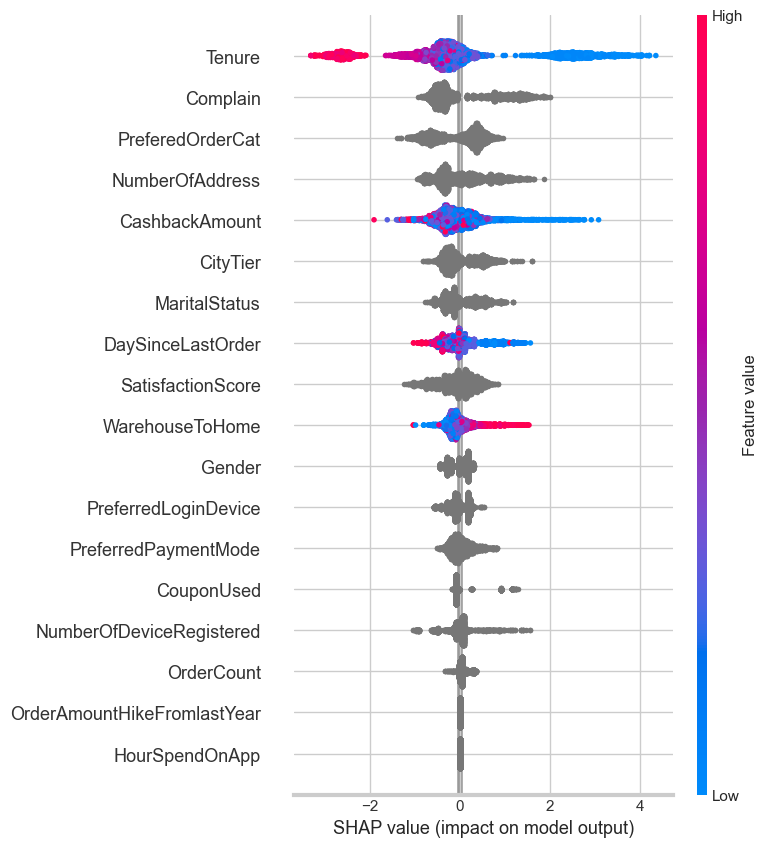

In [ ]:
#Shap Explanability on Catboost Model

import shap

# print the JS visualization code to the notebook
shap.initjs()

explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)


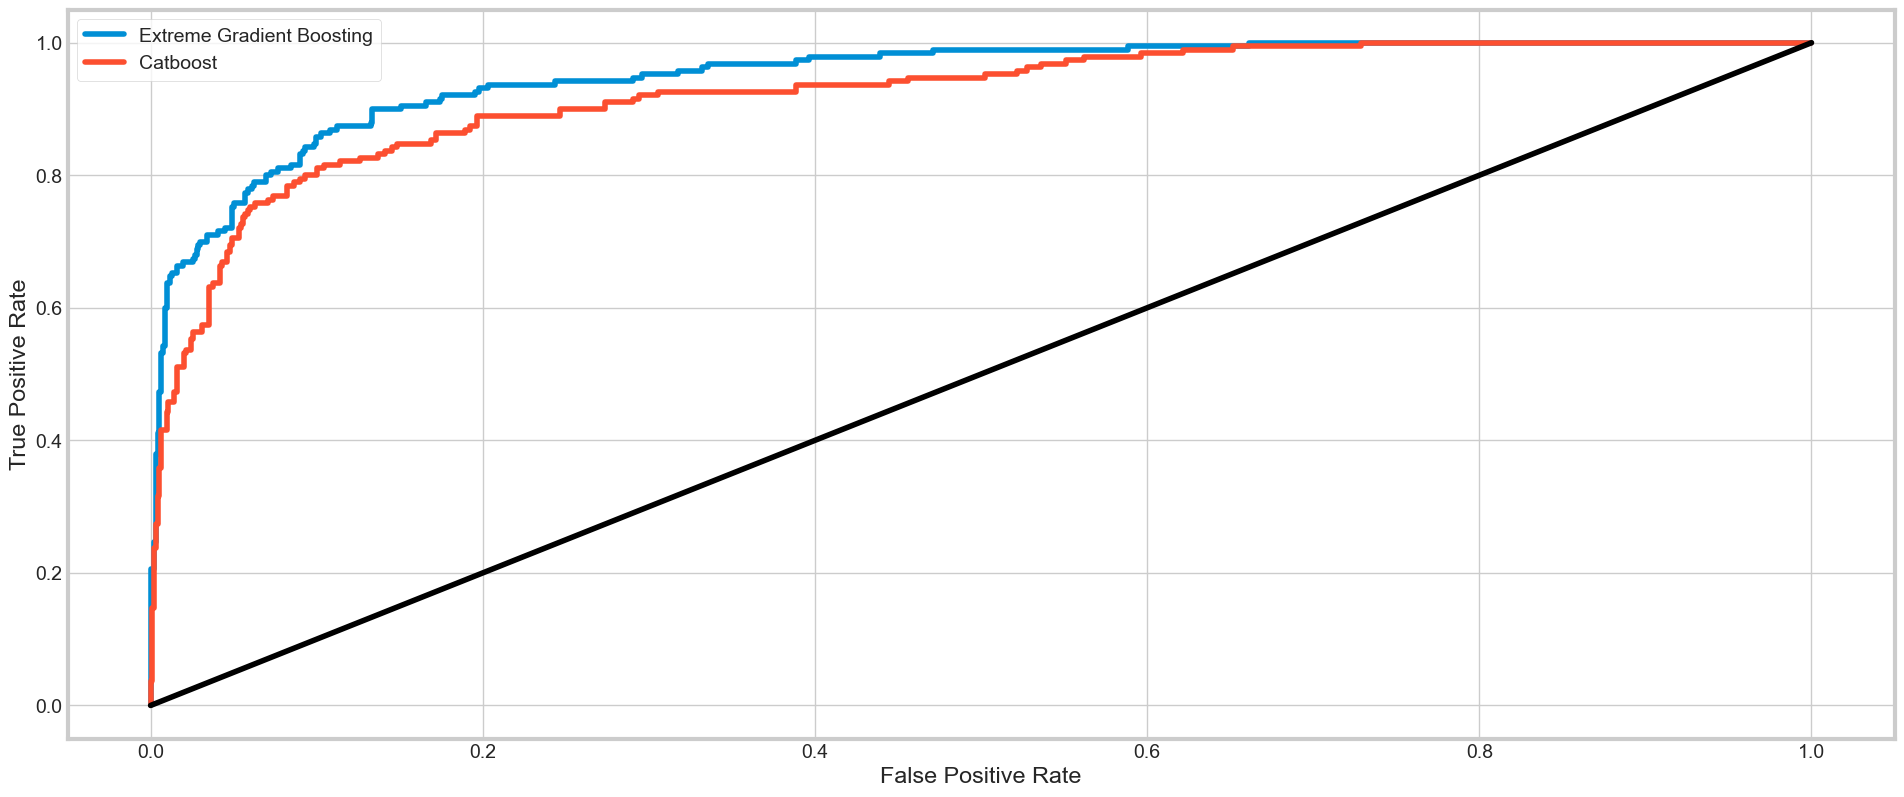

In [ ]:
## Evaluate CatBoost model and XGBoost model on the test set
# Convert all object columns in X_test to category for XGBoost compatibility
for col in X_test.select_dtypes(include='object').columns:
	X_test[col] = X_test[col].astype('category')

models_list = [xgb_best, catboost_model]
model_names = ['Extreme Gradient Boosting', 'Catboost']

plt.figure(figsize=(21, 9))
[add_roc_plot(model, X_test, y_test, legend_text) for model, legend_text in zip(models_list, model_names)]

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot([0, 1], [0, 1], "k-")
plt.show()

In [ ]:
# Calculate and display scores for both models

list_scores = [roc_auc_score, recall_score, precision_score, accuracy_score]
calc_scores = []

def compute_scores(model, x_test, y_test, scores):
    # Ensure both y_test and predictions are integer type for all metrics
    y_test_int = y_test.astype(int) if y_test.dtype == object else y_test
    y_pred = model.predict(x_test)
    # Convert predictions to int if they are strings
    if y_pred.dtype.kind in {'U', 'S', 'O'}:
        y_pred = y_pred.astype(int)
    return [round(score(y_test_int, y_pred), 2) for score in scores]
    
[calc_scores.append(compute_scores(model, X_test, y_test, list_scores)) for model in models_list]

score_names = ['roc_auc', 'recall', 'precision', 'accuracy']
scores_df = pd.DataFrame(calc_scores, columns=score_names, index=model_names)

scores_df

,roc_auc,recall,precision,accuracy
Extreme Gradient Boosting,0.60,0.21,0.95,0.86
Catboost,0.77,0.58,0.77,0.90


**7. Prediction of High-Risk Churning Customers**

In [105]:
# 1. Select Your Best Model
# Based on  evaluation (scores_df), choose the best model.

final_churn_model = xgb_best # assuming XGBoost performed best based on your evaluation

print(f"Selected model for predicting high-risk customers: {type(final_churn_model).__name__}")

# 2. Prepare the Data for Prediction
# Ensure all categorical columns in X_to_predict are of type 'category'
if 'categorical_cols' not in locals():
    categorical_cols = X.select_dtypes(include='object').columns.tolist()

X_to_predict = X.copy() # Make a copy to avoid modifying the original X
for col in set(categorical_cols).intersection(X_to_predict.columns):
    X_to_predict[col] = X_to_predict[col].astype("category")

print("\nInfo of X_to_predict (full dataset prepared for model):")
X_to_predict.info()

# Predict churn probabilities for all customers in X_to_predict

churn_probabilities = final_churn_model.predict_proba(X_to_predict)[:, 1]


Selected model for predicting high-risk customers: XGBClassifier

Info of X_to_predict (full dataset prepared for model):
<class 'pandas.core.frame.DataFrame'>
Index: 5626 entries, 0 to 5629
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Tenure                       5626 non-null   float64 
 1   PreferredLoginDevice         5626 non-null   category
 2   CityTier                     5626 non-null   category
 3   WarehouseToHome              5626 non-null   float64 
 4   PreferredPaymentMode         5626 non-null   category
 5   Gender                       5626 non-null   category
 6   HourSpendOnApp               5626 non-null   category
 7   NumberOfDeviceRegistered     5626 non-null   category
 8   PreferedOrderCat             5626 non-null   category
 9   SatisfactionScore            5626 non-null   category
 10  MaritalStatus                5626 non-null   category
 11  Numb

In [106]:
# 3. Define "High-Risk" (Thresholding)
# Let's start with a common threshold of 0.5.
# (e.g., 0.3 for high recall, 0.7 for high precision).
churn_risk_threshold = 0.50

# Create a binary flag for high-risk customers
is_high_risk_churn = (churn_probabilities >= churn_risk_threshold).astype(int)


# 4. Generate a List of High-Risk Customers

# Use the CustomerID from the original df DataFrame, aligning indices with X
customer_ids_for_predictions = df.loc[X.index, 'CustomerID'].values


customer_churn_predictions = pd.DataFrame({
    'customerID': customer_ids_for_predictions,
    'Predicted_Churn_Probability': churn_probabilities,
    'Is_High_Risk_Churn': is_high_risk_churn,
    'Actual_Churn': y.values # Include actual churn for validation/reporting
})

# Sort by predicted probability to see the highest-risk customers first
customer_churn_predictions_sorted = customer_churn_predictions.sort_values(
    by='Predicted_Churn_Probability', ascending=False
).reset_index(drop=True)

print("\n--- Top 20 High-Risk Churn Customers (by Predicted Probability) ---")
print(customer_churn_predictions_sorted.head(20))

# Get a count of high-risk customers
num_high_risk = customer_churn_predictions_sorted['Is_High_Risk_Churn'].sum()
print(f"\nTotal identified high-risk churn customers (probability >= {churn_risk_threshold}): {num_high_risk}")




--- Top 20 High-Risk Churn Customers (by Predicted Probability) ---
    customerID  Predicted_Churn_Probability  Is_High_Risk_Churn Actual_Churn
0      55530.0                     0.697903                   1            1
1      53402.0                     0.685453                   1            1
2      54872.0                     0.685453                   1            1
3      52821.0                     0.685435                   1            1
4      50006.0                     0.683187                   1            1
5      54060.0                     0.679647                   1            1
6      51245.0                     0.675215                   1            1
7      54675.0                     0.673609                   1            1
8      52715.0                     0.672805                   1            1
9      52817.0                     0.671913                   1            1
10     54163.0                     0.671913                   1            1
11     

In [107]:
# **Part 5: Saving the High-Risk Customer List**

# Save the list of high-risk customers to a CSV file for the marketing team

high_risk_customer_list = customer_churn_predictions_sorted[
    customer_churn_predictions_sorted['Is_High_Risk_Churn'] == 1
].copy() # Use .copy() to avoid SettingWithCopyWarning

output_filename = "high_risk_churn_customers.csv"
high_risk_customer_list.to_csv(output_filename, index=False)

print(f"\nList of high-risk churn customers saved to: {output_filename}")
print(f"Number of high-risk customers in the saved file: {len(high_risk_customer_list)}")

# Display a sample of the saved file's content
print("\nSample of the saved high_risk_churn_customers.csv:")
print(pd.read_csv(output_filename).head())



List of high-risk churn customers saved to: high_risk_churn_customers.csv
Number of high-risk customers in the saved file: 351

Sample of the saved high_risk_churn_customers.csv:
   customerID  Predicted_Churn_Probability  Is_High_Risk_Churn  Actual_Churn
0     55530.0                     0.697903                   1             1
1     53402.0                     0.685454                   1             1
2     54872.0                     0.685454                   1             1
3     52821.0                     0.685435                   1             1
4     50006.0                     0.683187                   1             1
